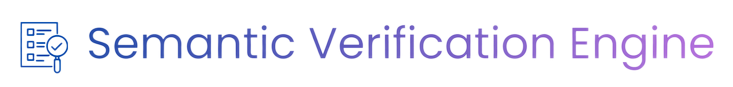

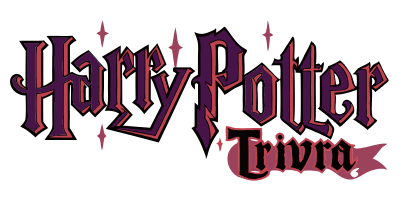

<div style="background-color: #f0e6f7; padding: 10px;">
    <h3 style="text-align:center; color:purple;">Phase 2: Content Factory, core logic for the Validation pipeline (Synthetic dataset) </h3>
</div>

## Validation and Compilation of Tracer Silver Dataset (Sprint 2.3)
### Synthetic tracer dataset validation workflow

**Goal**: Tracer validation logic test. Quality assurance and validation of the Legacy and Synthetically generated Tracer datasets required to raise to Silver level<br>

---

## 1: Strategy and Workflow

- The current tracer handles only three types of questions: [Factual Recall (FR)| Explanatory (EX), Multiple-choice (MCQ)]
- The validation is a part of the *Content Factory* (offline content generation subsystem). The content factory follows a *Medallion* approach summarized below (see [Design Doc](../../docs/00_DESIGN_DOC_AND_ARCHITECTURE.md) for more detail).<br>

    [Bronze data input (Legacy / Synthetic)] → *QA & Validation* →  [Silver dataset] → *Final processing for publishing /lifecycle* → [Gold dataset]

- The focus of this notebook is the **Quality Assurance (QA) and validation** stage.

### 1.1: Methdology
The `qa_validation` pipeline will recieve input from two sources:
 - Legacy dataset: hugging dataset verified with manual quality assurance in phase 1 (ground truth)
 - Sythetic dataaset: Generated by LLMs to augment and grow the legacy dataset. Provide balance in question types and better source material coverage.

As a result, the `qa_validation` pipeline will have two separate operating states:
1. **Legacy baseline**: This is a bootstrap script to initialize the Gold dataset. It will run once at the start before any synthetic data addtions and establishes the Gold baseline. This is to establish Legacy (human-validated) presence supercedes Synthetic (LLM-genrated) questions.
2. **Synthetic**: normal, recurring operating mode of the pipeline. This will always run after the Gold Baseline Dataset is in-place. The LLM can generate duplicates within the same type since the different question types (FR, EX, MCQ) are generated by rerunning the different prompts on the same ground text. A predefined hierarchy will be used to determine precedence for which questions are retained:

    | Question type | Precedence level | Rational |
    |-|-|-|
    | EX| 1 (highest)| More lore-rich, greatest SBERT answer checking payoff, low count in Legacy |
    | MCQ| 2| Variety, low count in Legacy, makes hard concepts more accessible |
    | FR | 3 (lowest)| Majority in Legacy, simple |


### 1.2: Data Contract
This table describes how the data will be managed through the pipeline: 

|**Column \ Dataset**| **Legacy**<br>(input) | **Synthetic**<br>(input) | **Silver**<br>(validation output)| **Gold**<br>(final SOT) |**Final Gold Dtype**|
|-|-|-|-|-|-|
|`original_question_id`|✓|x|✓|~(lineage only)|int|
|`temp_qid`|x|✓|✓|x|object (str)|
|`gold_id`|x|x|x|✓|int|
|`question_source`|✓|✓|✓|✓|enum category|
|`question_type`|✓|✓|✓|✓|enum category|
|`question`|✓|✓|✓|✓|object (str)|
|`answer`|✓|✓|✓|✓|object (str)|
|`answer_variations`|✓|✓|✓|✓|object (list[str])|
|`llm_predicted_category`|x|✓|✓|x|object (str)|
`llm_predicted_difficulty`|x|✓|✓|x|object (str)|
|`source_reference`|x|✓|✓|✓|object (str)|
|`source_quote`|x|✓|✓|✓|object (str)|
|`mcq_options`|✓|✓|✓|✓|object (list[str])|
|`hint_(1 to 3)`|✓|✓|✓|✓|object (str)|
|`explanation`|✓|✓|✓|✓|object (str)|
|`semantic_entity_refs`|✓|✓|✓|✓|object (list[str])|
|`semantic_lore_concepts`|✓|✓|✓|✓|object (list[str])|
|`question_embeddings`|x|x|✓|✓|object(float)|
|`answer_embeddings`|x|x|✓|✓|object(float)|
|`answer_variations_embeddings`|x|x|✓|✓|object(float)|
|`mcq_options_embeddings`|x|x|✓|✓|object(float)|
|`source_quote_embeddings`|x|x|✓ (synthetic only)|✓ (synthetic only)|object(float)|

### 1.3: Validation Workflow

The pipeline itself will have defined processing stages:

1. Structure: Overall dataset structure lookin at schema adherence, nulls, missing values
2. Deduplication (inter / intra): for synthetic dataset between question types from the same batch, against existing gold. 
3. Alignment: Augmented fields are in line with core question and answer
3. Embeddings: add refrence sbert embeddings for question and answers
4. Finalization: spelling, id and question uniqueness, column ordering, dtype assignment. 

Since this is a tracer run, the workflow will focus on the core, basic logic and optimizations will be addressed in the next stage.

1. **Legacy:**

    |**Column**| **Source**|**Trust level**| **Validation Stage**|**Silver dataset Admission**|
    |-|-|-|-|-|
    |`original_question_id`|Validated baseline (Phase 1)|High|Structure|non-null; Integrity check: must exist and be unique|
    |`question`|Validated baseline (Phase 1)|High|Structure|High|Structure|non-null|
    |`answer`|Validated baseline (Phase 1)|High|Structure|Structure|non-null|
    |`answer_variations`|LLM augmented|Medium|Alignment|Must align semantically with answer|
    |`mcq_options`|LLM augmented|Medium|Alignment|Required if question_type == MCQ,<br> distractors semantically distinct from answer|
    |`hint_(1 to 3)`|LLM augmented|Medium|Alignment|Must align semantically with answer|
    |`explanation`|LLM augmented|Medium|Alignment|Must align semantically with answer|
    |semantic metafields<br>`entity_refs, lore_concepts`|LLM augmented|Medium|Alignment|Must align semantically with question, answer|

<br>

2. **Synthetic:**

    |**Column**| **Source**|**Trust level**| **Validation Stage**|**Silver dataset Admission**|
    |-|-|-|-|-|
    |`temp_qid`|LLM generated|High|Structure|non-null; Integrity check: must exist and unqiue|
    |`question`|LLM generated|Medium|Deduplication|non-hallucinated, unique, new|
    |`answer`|LLM generated|Medium|Deduplication|non-null, must align with question|
    |`answer_variations`|LLM generated|Medium|Alignment|Must align semantically with answer|
    |`llm_predicted_category`|LLM generated|low|Alignment<br>(diagnostic)|Question / answer match assigned category|
    |`llm_predicted_difficulty`|LLM generated|low|Alignment<br>(diagnostic)|non-null|
    |`source_reference`|LLM generated|High|Deduplication|Must match batch source text|
    |`source_quote`|LLM generated|High|Deduplication|a clear extraction from the source reference|
    |`mcq_options`|LLM augmented|Medium|Alignment|Required if question_type == MCQ,<br> distractors semantically distinct from answer|
    |`hint_`(1-3)|LLM augmented|Medium|Alignment|Must align semantically with answer|
    |`explanation`|LLM augmented|Medium|Alignment|Must align semantically with answer|
    |semantic metafields<br>`entity_refs, lore_concepts`|LLM augmented|Medium|Alignment|Must align semantically with question, answer|


    **Note**: synthetic problematic questions are dropped (not corrected). " Rearranged it for better flow and clarity - it is not supposed to be polished but give the sense of the notebook purpose.

- Load the legacy and tracer datasets.
- Start with the Synthetic dataset - more involved and common methods can be leveraged for the simpler processing of the Legacy dataset.

# 2: Setup & Imports

In [1]:
#  STANDARD NOTEBOOK SETUP
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append('..')
# --- Core Libraries ---
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import numpy as np
import torch
import json
from pathlib import Path
# --- Project-Specific Imports ---
import ds_utils.notebook_config as nb_cfg
from ds_utils import eda_scripts as eda
from ds_utils.ds_constants import DataTier, QuestionType, QuestionSource
import ds_utils.tracer_validation_v0 as val
# --- Common Settings ---
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 20)

✅ Notebook config loaded.


In [2]:
# load the synthetic tracer dataset
synthetic_df = pd.read_parquet(nb_cfg.INTERMEDIATE_DATA_DIR / "dataframe_nb6_tracer_synthetic_v0.parquet")

In [3]:
# synthetic 
synthetic_df.info()
print("\n","-"*50, "\nCount of Question Types")
print(synthetic_df.groupby('question_type', observed=True).size().reset_index(name='count'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   temp_qid                        50 non-null     object
 1   question_type                   50 non-null     object
 2   llm_predicted_category          50 non-null     object
 3   llm_predicted_difficulty        50 non-null     object
 4   question                        50 non-null     object
 5   answer                          50 non-null     object
 6   source_reference                50 non-null     object
 7   source_quote                    50 non-null     object
 8   mcq_options                     18 non-null     object
 9   question_source                 50 non-null     object
 10  hint_1                          50 non-null     object
 11  hint_2                          50 non-null     object
 12  hint_3                          50 non-null     obje

As you can see, the Synthetic dataset has more columns than the Legacy dataset. This is why they will require different schema validation.

> **Note**: Going forward all validation logic was developed and iterated in a separate [**module**.](../../../src/ds_utils/tracer_validation_v0.py)

# 3: Synthetic Dataset validation

## 3.1: Stage 1: Structural validation

1. Pydantic check (checks for schemas, nulls in any required fields) 
2. Normalize and preprocessing 
    - unicode normalization (e.g. apsotrophe issue keeps showing up)
    - stripping whitespace
    - all lower case
    - remove punctuation
3. check if / how spelling check can be used.

### 3.1.1: Schema validation using Pydantic V2

In [4]:
# create a sample 
RANDOM_SEED=26

syn_sample = synthetic_df.groupby('question_type').sample(1, random_state=RANDOM_SEED)
syn_sample[['temp_qid','question_type','question','answer']]

,temp_qid,question_type,question,answer
8,SYN_008,EX,"During the Battle of Hogwarts, why did Hermion...",Hermione understood that Nagini was Lord Volde...
17,SYN_017,FR,What was Professor McGonagall's answer to the ...,Into non being
37,SYN_037,MCQ,What inscription was etched upon the lost Diad...,WIT BEYOND MEASURE IS MAN'S GREATEST TREASURE.


In [5]:
# pass sample through Pydantic checker (method in tracer_validation_v0.py module)

# setup
source = QuestionSource.SYNTHETIC
tier = DataTier.BRONZE
df = syn_sample

# validate synthetic samples using Pydantic models 
validated_syn_sample, flagged_syn_sample = val.enforce_schema(source, tier, df)

# review results
print(f'Total records: {len(syn_sample)}')
print(f'Records validated: {len(validated_syn_sample)}')
print(f'Records flagged: {len(flagged_syn_sample)}')

TRACER RESULTS: 3 validated, 0 flagged
Total records: 3
Records validated: 3
Records flagged: 0


In [6]:
# stress test the Pydantic model
syn_sample_stress = syn_sample.copy()
# case 1: MCQ options is missing
syn_sample_stress.loc[syn_sample_stress['question_type']=='MCQ','mcq_options']= None
# case 2: FR missing explanation
syn_sample_stress.loc[syn_sample_stress['question_type']=='FR','explanation']= None
# case 3: EX, answer variations is an empty list
idx = syn_sample_stress[syn_sample_stress['question_type']=='EX'].index[0]
syn_sample_stress.at[idx, 'answer_variations'] = []  # type: ignore

validated_syn_sample_stress, flagged_syn_sample_stress = val.enforce_schema(source, tier, syn_sample_stress)

# review results
print(f'Total records: {len(syn_sample_stress)}')
print(f'Records validated: {len(validated_syn_sample_stress)}')
print(f'Records flagged: {len(flagged_syn_sample_stress)}')

Skipping record SYN_008: 1 validation error for SyntheticStandard
  Value error, Must have at least 1 answer variation [type=value_error, input_value={'temp_qid': 'SYN_008', '..._variations_master.txt'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error
Skipping record SYN_017: 1 validation error for SyntheticStandard
explanation
  Input should be a valid string [type=string_type, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.12/v/string_type
Skipping record SYN_037: 1 validation error for SyntheticMCQ
mcq_options
  Input should be a valid list [type=list_type, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.12/v/list_type
TRACER RESULTS: 0 validated, 3 flagged
Total records: 3
Records validated: 0
Records flagged: 3


In [7]:
# test on the full synthetic tracer dataset
df = synthetic_df.copy()

# validate
validated_synthetic_df, flagged_synthetic_df = val.enforce_schema(source, tier, df)

# review results
print(f'Total records: {len(df)}')
print(f'Records validated: {len(validated_synthetic_df)}')
print(f'Records flagged: {len(flagged_synthetic_df)}')

TRACER RESULTS: 50 validated, 0 flagged
Total records: 50
Records validated: 50
Records flagged: 0


In line with the pipeline flow. For further processing, we will use `validated_synthetic_df`. 

### 3.1.2: Normalization of text

**Normalizing steps:**
1. normalize unicode (e.g. change curly speech marks to straight - LLMs frequently return curly quotes that fail direct matching)
2. remove leading and trailing whitespaces
3. change text to lower case

**Keep punctuation**.
- better semantic signalling for SBERT layer in answer checker. All question types will fallback to SBERT if the earlier, more brittle layers (direct, fuzzy) fail.

**Selective columns will be normalized**: 
- **Applied**: Only fields used by answer checkers (`answer`, `answer_variations`, `mcq_options`).
- **Not applied**: Other columns that are UI-facing (e.g. `question`, `hint_1/2/3`, `explanation`) or semantic support columns (`semantic_lore_concepts`, `semantic_entity_refs`) will not be normalized and will remain in their original form.

**Rationale for preserving originals:**
- UI-facing columns maintain readability and proper formatting for players
- Semantic support columns retain proper nouns and context for SBERT embeddings
- Only answer-matching columns need normalization for Tier 1-2 (direct, fuzzy) comparison

In [8]:
## Test method with sample
# normalize columns:
columns = ['answer','answer_variations', 'mcq_options']
df = syn_sample.copy()

for col in columns:
    df[col] = df[col].apply(val.normalize_value)
df

,temp_qid,question_type,llm_predicted_category,llm_predicted_difficulty,question,answer,source_reference,source_quote,mcq_options,question_source,hint_1,hint_2,hint_3,explanation,answer_variations,semantic_entity_refs,semantic_lore_concepts,generation_model,generation_prompt_version,lex_enrich_prompt_version,semantic_enrich_prompt_version
8,SYN_008,EX,Character Arc/Motive,Medium,"During the Battle of Hogwarts, why did Hermion...",hermione understood that nagini was lord volde...,deathly_hallows Chapter 32,"Ron, we're the only ones who can end it! Pleas...",None,synthetic,Hermione always focused on the most critical s...,Nagini was more than just Voldemort's familiar...,True victory requires prioritizing the strateg...,Hermione understood that Nagini was Lord Volde...,[hermione prioritized nagini's destruction bec...,"[Hermione Granger, Nagini, Voldemort's last Ho...","[Horcrux hunt, Strategic priority, Voldemort's...",gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt
17,SYN_017,FR,Object/Potion,Medium,What was Professor McGonagall's answer to the ...,into non being,deathly_hallows Chapter 30,"""Where do Vanished objects go?"" ""Into non bein...",None,synthetic,The answer speaks to the philosophical state o...,McGonagall's response suggests they enter a re...,Her full reply includes a secondary clause abo...,Professor McGonagall answered the Ravenclaw ri...,"[into non being, non being]",[],"[Vanishing spell mechanics, Ravenclaw riddle a...",gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt
37,SYN_037,MCQ,Object/Potion,Hard,What inscription was etched upon the lost Diad...,wit beyond measure is man's greatest treasure.,deathly_hallows Chapter 31,He pulled the diadem from his wrist and held i...,"[knowledge is power., creativity and wisdom ab...",synthetic,The inscription reflects the core value of Rav...,Think about the specific quality that Ravencla...,The phrase emphasizes a particular intellectua...,The lost Diadem of Ravenclaw bore the inscript...,"[wit beyond measure, man's greatest treasure]","[Lost Diadem of Ravenclaw, Ravenclaw's Diadem]","[Ravenclaw motto, Founder's relic inscription,...",gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt


In [9]:
## Run normalization on the validated syn df
# create copy of df before transformation
normalized_synthetic_df = validated_synthetic_df.copy()

cols_to_normalize = ['answer','answer_variations', 'mcq_options']

for col in cols_to_normalize:
    normalized_synthetic_df[col] = normalized_synthetic_df[col].apply(val.normalize_value)

normalized_synthetic_df[['question','question_type']+ cols_to_normalize].groupby('question_type').head(1)

,question,question_type,answer,answer_variations,mcq_options
0,"Why did Helena Ravenclaw, the Gray Lady, revea...",EX,she confessed to riddle because he was flatter...,[helena confessed to riddle because he flatter...,NaN
16,"In Ravenclaw Tower, what was the effect of the...",FR,stunned,"[stunned, knocked out, incacipated, made uncon...",NaN
32,What was Luna Lovegood's initial reaction to s...,MCQ,"she noted it was noisier than expected, having...","[noisyer than expected, d.a. lessons]",[she was surprised by the spell's effectivenes...


In [10]:
normalized_synthetic_df.shape[1]

21

## 3.2: Stage 2: Deduplication & contextual integrity checks

1. **Deduplication**
    - First-pass: batch data by prompt grounding text because they are all from the same source text - most likely occurence for a duplicate. For each batch level, check for duplicates across question types using sbert similarity between source_quotes.
    - Second-pass: full dataset level screening in case common questions (e.g. important themes repeated in other chapters, source quote differs but context, question are the same) are repeated across chapters.
2. **Contextual integrity checks** <br>
    - are there any questions and answers that might were hallucinated?
    - confirm the questions are grounded and aligned with the source text.

### 3.2.1: Batch level deduplication
Edge cases identified during the [Synthetic Tracer dataset generation](06_Synthetic_dataset_generation.ipynb#edge-cases-for-downstream-logic-for-synthetic-questions):

||**Test Case**| **Question IDs**|**Desired result**|
|-|-|-|-|
|1| EX vs. MCQ|SYN_006 & SYN_038|Flagged as duplicates|
|2| EX vs. FR|SYN_009 & SYN_021|Flagged as duplicates|
|3| MCQ vs. FR|SYN_040 & SYN_024|Flagged as duplicates|
|4 (new)*| MCQ vs FR| SYN_032 & SYN_016| NOT flagged as duplicates|

**Note** *: Case 4 identified in sampling below.

#### Approach

**A. First pass: micro-batch deduplication by soure text**. Cross-type duplicates are most likely to be generated from the same trivia kernel (`source_quote`). So we can make the runs efficient by looking for duplicates of question types grouped together by their source text.
- Each API call used two grounding chapters for three question types, generating 5 to 6 questions per type.
- To account for potential context bleed (LLM misquoting or overlapping scenes between the two chapters in a single call), these chapters are batched together.
- *Batch size*: ~15 questions / batch and 3 batch runs.
- *Pairwise comparison* a matrix of ~15 x ~15 questions per batch. 
- *source reference* the generation pipeline metadata will define which chapter are batched together and this would be shared with the validation pipeline.
- We know from the Synthetic tracer dataset was generated from 6 chapters (30-35) from Book 7 (see [notebook](06_Synthetic_dataset_generation.ipynb) for details). The chapters were paired sequentionally.

**B. Second pass: full synthetic dataset sweep** Once the batch-level duplicates are removed, the second pass provides a clearer signal for remaining duplicates. Since chapters are not mutually exclusive (they can recall previous events or motifs), a global pass might be needed.
- *Threshold*: can set higher than the first pass for precision and avoid false positives.

**For each pass:**
1. Create embeddings with SBERT for `source_quote`, `answer`, and `question` columns.
2. Apply cosine similarity matrices and graph analysis to group similar questions (adapt phase 1 prototype script). Compare results of individual columns (`source_quote` only) vs.  combinations (`source_quote`, `question`, `answer`).
3. select a reasonable threshold as standard.
4. use defined question type hierarchy from [section 1.1](#11-methdology) to decide which question should be retained.

So with the tracer dataset run we can confirm:
1. if the micro-batching is effective? is there context bleed between chapters (ie. incorrect source_reference)
2. is the second pass over the whole dataset needed?
3. What are reasonable thresholds for each deduplication pass.

#### Evaluation

*A. Generation redundancy*: Total number of duplicates identified. Synthetic questions were generated from the same 6 chapters (with 5~6 questions generated per chapter) and 50 questions in total.

*B. Duplicate detection effectiveness*
- Precision at selected threshold (how many flagged questions actually are duplicates).
- Optional: recall at selected threshold (how many of all the duplicates in the dataset were actually detected?)
- Threshold robustness / sensitivity analysis
- false positives? consider comparison options for detection, e.g:
    - source_quote only
    - source_quote, answer, question similarity comparisons

In [11]:
normalized_synthetic_df.shape

(50, 21)

In [12]:
# create sample:
dedup_df = normalized_synthetic_df.copy()
view_cols = ['temp_qid','question_type', 'question', 'answer','source_quote', 'source_reference']

dedup_sample_df = dedup_df.groupby('question_type').head(1)
dedup_sample_df[view_cols]

,temp_qid,question_type,question,answer,source_quote,source_reference
0,SYN_000,EX,"Why did Helena Ravenclaw, the Gray Lady, revea...",she confessed to riddle because he was flatter...,"You've already told someone this story, haven'...",deathly_hallows Chapter 30
16,SYN_016,FR,"In Ravenclaw Tower, what was the effect of the...",stunned,"""I've never Stunned anyone except in our D.A. ...",deathly_hallows Chapter 30
32,SYN_032,MCQ,What was Luna Lovegood's initial reaction to s...,"she noted it was noisier than expected, having...",I've never Stunned anyone except in our D.A. l...,deathly_hallows Chapter 30


**New edge test case (#4)**: The selected samples are interesting because the FR (SYN_016) and MCQ (SYN_032) questions are sourced from the same kernel but ask different things. Here, the source quote is identical, the answers are different, and the questions are semantically similar and reference the same entitites (Luna Lovegood and Aldecto Carrow). So this is a great test for False Positives in deduplication.

In [13]:
# 1. Load model
sbert_model = SentenceTransformer(val.SBERT_MODEL_NAME)

# 2. create embeddings for selected columns 
dedup_embedding_cols = ['question', 'answer', 'source_quote']

# 3. create embeddings using helper method from the validation module
dedup_sample_embedding_df = val.generate_embeddings(
    dataframe = dedup_sample_df,
    columns = dedup_embedding_cols, 
    model = sbert_model)

In [14]:
## convert answer_variations str list - list of dicts with 'text', 'embedding' keys
def embed_variations(variation_list):
    """
    Takes a list of answer variation strings and returns a list of dicts with 'text' and 'embedding' keys.
    """
    # encode the list in one go and convert np array to list
    embeddings = sbert_model.encode(variation_list).tolist()
    # zip the text, embedding toget into a dict for each variation
    structured_variations = [
        {"text": text, "embedding": emb} for text, emb in zip(variation_list, embeddings)
    ]
    return structured_variations

dedup_sample_embedding_df['answer_variations'] = dedup_sample_embedding_df['answer_variations'].apply(embed_variations)
dedup_sample_embedding_df.info()
dedup_sample_embedding_df

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 0 to 32
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   generation_model                3 non-null      object
 1   generation_prompt_version       3 non-null      object
 2   lex_enrich_prompt_version       3 non-null      object
 3   semantic_enrich_prompt_version  3 non-null      object
 4   question_type                   3 non-null      object
 5   question_source                 3 non-null      object
 6   question                        3 non-null      object
 7   answer                          3 non-null      object
 8   answer_variations               3 non-null      object
 9   hint_1                          3 non-null      object
 10  hint_2                          3 non-null      object
 11  hint_3                          3 non-null      object
 12  explanation                     3 non-null      object
 13

,generation_model,generation_prompt_version,lex_enrich_prompt_version,semantic_enrich_prompt_version,question_type,question_source,question,answer,answer_variations,hint_1,hint_2,hint_3,explanation,semantic_entity_refs,semantic_lore_concepts,temp_qid,llm_predicted_category,llm_predicted_difficulty,source_reference,source_quote,mcq_options,question_embeddings,answer_embeddings,source_quote_embeddings
0,gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,EX,synthetic,"Why did Helena Ravenclaw, the Gray Lady, revea...",she confessed to riddle because he was flatter...,[{'text': 'helena confessed to riddle because ...,Consider how Tom Riddle typically manipulated ...,The difference lay in Riddle's emotional appro...,The ghost was susceptible to appeals that vali...,Helena confessed to Riddle because he flattere...,"[Helena Ravenclaw, The Gray Lady, Tom Riddle, ...","[Horcrux creation, Flattery and manipulation, ...",SYN_000,Character Arc/Motive,Hard,deathly_hallows Chapter 30,"You've already told someone this story, haven'...",NaN,"[0.006492754444479942, -0.03948007896542549, 0...","[-0.032345108687877655, -0.029494332149624825,...","[0.028978172689676285, 0.05731399729847908, 0...."
16,gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,FR,synthetic,"In Ravenclaw Tower, what was the effect of the...",stunned,"[{'text': 'stunned', 'embedding': [-0.02279229...",The effect of the spell renders the target unc...,Luna noted the spell was 'noisier than I thoug...,This is a very common defensive spell that tem...,"Luna Lovegood used a Stunner on Alecto Carrow,...",[],"[Stunning spell effect, Stupefy charm, Magical...",SYN_016,Spell/Charm,Easy,deathly_hallows Chapter 30,"""I've never Stunned anyone except in our D.A. ...",NaN,"[0.027551548555493355, 0.04513787850737572, 0....","[-0.022792335599660873, 0.03067617304623127, 0...","[-0.0328238345682621, 0.027827011421322823, 0...."
32,gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,MCQ,synthetic,What was Luna Lovegood's initial reaction to s...,"she noted it was noisier than expected, having...","[{'text': 'noisyer than expected', 'embedding'...","Consider Luna's perspective on using magic, es...",What did she compare the sound of the stunning...,Luna often expresses unique and unfiltered obs...,"Upon successfully stunning Alecto Carrow, Luna...","[Luna Lovegood, Stunning Spell]","[Dumbledore's Army training, Spell execution e...",SYN_032,Spell/Charm,Medium,deathly_hallows Chapter 30,I've never Stunned anyone except in our D.A. l...,[she was surprised by the spell's effectivenes...,"[0.006097486242651939, 0.019398074597120285, 0...","[0.04727756232023239, -0.012783628888428211, 0...","[-0.023542018607258797, -0.020406626164913177,..."


We can see that three embedding columns (# 17, 18, 19) were appended to the end of the dataframe. 

In [15]:
# sanity checks 1 - simple str col e.g. 'answer'
sample_ans1 = dedup_sample_embedding_df['answer_embeddings'].iloc[0]
assert type(sample_ans1) == list, "The sample answer embedding is not type list"
assert len(sample_ans1) == 384, "The vector length does not match expected sbert embedding length of 384"
# visual of first 5 elements
print(sample_ans1[:5])

[-0.032345108687877655, -0.029494332149624825, 0.03867486119270325, 0.07374823093414307, 0.01742781512439251]


The embeddings are the correct data type and length.

In [16]:
## Test if embeddings are correct
# use FR answer (SYN_032) -> "stunned"
ref_emb = dedup_sample_embedding_df['answer_embeddings'].iloc[1]
ref_ans_text = dedup_sample_embedding_df['answer'].iloc[1]
print(f"Reference answer: '{ref_ans_text}'")

# compare generated embedding for SYN_032 answer with test good and bad matches:
tests = {
    'Positive' : 'stupefy',
    'Negative' : 'run',
    'Neutral'  : 'yell'
}

for k, v in tests.items():
    embedding = sbert_model.encode(v).tolist()
    cos_sim_score = util.cos_sim(embedding, ref_emb).item()
    print(f"{k} test score ('{v}'): {cos_sim_score: .3f}")

Reference answer: 'stunned'
Positive test score ('stupefy'):  0.622
Negative test score ('run'):  0.167
Neutral test score ('yell'):  0.268


The sbert embeddings have performed correctly:

1. The positive score is clearly distinguishable from the others. It is interesting that the score is 0.622 and not higher with the vanilla sbert. With fine-tuning the model would recognize that *stupefy* is actually the spell that results in stunning and give a higher similarity score. 
    - So on its own this score would make the answer ambigious. But when taking into account other fields e.g. answer variations, semantic entity references, and semantic lore concepts, we can anticipate that the vanilla model can also show better discernment.
2. The negative score is very low, clearly not related to *stunned* at all. 
3. The neutral score is higher than the negative but still clearly not related to the reference. It probably scored higher maybe because they are high-energy states and can occur together rarely.

#### A: First pass deduplication
For the tracer synthetic dataset, the questions were generated from *Harry Potter and the Deathly Hallows*, chapters 30 to 35. We can batch the synthetic questions in chapter pairings that match the source text pairing in their generation prompt. In the pipeline this data would be available both in the generation strategy dict and the pipeline run data 

We can start by creating a dict of the batches that we want to deduplicate within.

In [17]:
# batching strategy for first-pass deduplication
generation_batches = {
    'batch_1' : ['deathly_hallows Chapter 30', 'deathly_hallows Chapter 31'],
    'batch_2' : ['deathly_hallows Chapter 32', 'deathly_hallows Chapter 33'],
    'batch_3' : ['deathly_hallows Chapter 34', 'deathly_hallows Chapter 35']
}

- first we loop through the df and create subsets of the df based on the `generation_batches`. 
- Then for each subset, if not empty:
    - take each of the embeddings columns and convert them to tensors. This is because the SBERT embeddings are large, dense vectors (len = 384), we need to convert the tensors for efficient computing.
    - the tensors are then converted in len(subset) x len(subset) similarity matrix.
    - each similarity matrix for a given column is stored within a nested dict (batch_sim_matrix[batch name][embedding col]).
    - we need to make sure that this done only for non-empty subsets otherwise pytorch creates empty placeholder tensors `tensor([[0.]])` that bload the similarity matrix dict.

In [18]:
# now we can compare the similarity scores for the sample:
dedup_embedding_cols = ['question_embeddings','answer_embeddings','source_quote_embeddings']
batch_sim_matrix = {}
df_syn_test = dedup_sample_embedding_df

for batch_name, chapters in generation_batches.items():
    # create subset of questions for each generation batch
    subset = df_syn_test.loc[df_syn_test['source_reference'].isin(chapters)]
    # prevent creating empty tensor placeholders for batches with no matching data
    if not subset.empty:
        batch_sim_matrix[batch_name] = {}
        # lock in the parallel array of question ids to map back from tensor coordinates
        batch_sim_matrix[batch_name]['batch_qids'] = subset['temp_qid'].tolist()
        for col in dedup_embedding_cols:
            # because sbert embeddings are dense vectors can use tensors for fast simillilarity calc
            tensor = torch.tensor(subset[col].tolist())
            # convert to numpy after calc to work with graphs (networkx, pandas)
            batch_sim_matrix[batch_name][f"{col}_sim_matrix"] = util.cos_sim(tensor, tensor).numpy()
    else:
        print(f"Skipping {batch_name}: no matching chapters found in current data.")
        
# method converted to a helper in `tracer_validation_v0.py`                

Skipping batch_2: no matching chapters found in current data.
Skipping batch_3: no matching chapters found in current data.


The deduplication sample has three questions of each question type and all three have the same grounding chapter (# 30). They are all part of batch 1 and batches 2 and 3 are empty.

In [19]:
# sanity check - all three sample questions are from the same chapter (#30)
for batch_name, inner in batch_sim_matrix.items():
    for key, value in inner.items():
        # If the value is the id list, print its length
        if key == 'batch_qids':
            print(batch_name, key, f"Length: {len(value)}")
        # Otherwise, it's a tensor, so print its shape
        else:
            print(batch_name, key, value.shape)

batch_1 batch_qids Length: 3
batch_1 question_embeddings_sim_matrix (3, 3)
batch_1 answer_embeddings_sim_matrix (3, 3)
batch_1 source_quote_embeddings_sim_matrix (3, 3)


In [20]:
batch_sim_matrix.get('batch_1')

{'batch_qids': ['SYN_000', 'SYN_016', 'SYN_032'],
 'question_embeddings_sim_matrix': array([[1.0000001 , 0.3360753 , 0.23747794],
        [0.3360753 , 1.0000006 , 0.7580666 ],
        [0.23747788, 0.7580669 , 1.        ]], dtype=float32),
 'answer_embeddings_sim_matrix': array([[1.0000002 , 0.06837355, 0.37625605],
        [0.06837355, 1.0000001 , 0.13724296],
        [0.37625596, 0.13724296, 1.        ]], dtype=float32),
 'source_quote_embeddings_sim_matrix': array([[1.0000004 , 0.4828735 , 0.415675  ],
        [0.4828735 , 0.99999994, 0.91259617],
        [0.41567487, 0.91259605, 1.        ]], dtype=float32)}

**Logic for deduplication**: 
1. flatten the matricies so that a composite matrix holds all three similarity scores (source quote, answer, question)
2. group questions with source_quote similarity at testing threshold (0.7 to 0.85) using graphs (primary filtering)
3. Within the group select the golden record based on hierarchy (i.e. EX > MCQ > FR).
4. Then, against golden record in the group, flag duplicates based on secondary screening cols (answer, questions) with their own specific thresholds (this can be a helper - turned on / off to see the affect of using multiple columns for screening in the tracer) - confirm duplicates and not false positives
    - a duplicate is where source_quote are similar, the answer is similar and the question is somewhat similar (because they are different types, EX vs MCQ for example).
    - a likely false positive: source quote meets threshold, question meets threshold, answer does not meet threshold
    - a missed duplicate from the coarse - is a question that meets the duplicate requirements but was marked is_duplicate = false in the group. <- we have to make sure only records that are not golden records within the group are considered?
    - orphan - incorrectly grouped question

    Scenario|Source Quote|Question|Answer|Action / Label|
    |-|-|-|-|-|
    |Definite Duplicate|High |High/Medium|High|is_duplicate = True remains|
    |Format Shift|High|Low/Medium|High|Likely duplicate where e.g. an MCQ was turned into an Explanation (EX) or vice versa. Flag as Duplicate.
    False Positive|High|High|Low|Same context, same question, but different answer? This is likely a *variation* not a duplicate. Keep both.
    |Adjacent Question|High|Low|Low|Different questions derived from the same quote. (e.g., Quote talks about Harry and Ron; Q1 asks about Harry, Q2 asks about Ron). Not a Duplicate.



5. Review and drop dulicates
6. Select methodology to go forward and similarity thresholds for comparisons for the full synthetic tracer run.

--> the second pass then becomes a pass through of the full dataset through the same logic - with tighter thresholds.

In [21]:
df_syn_test

,generation_model,generation_prompt_version,lex_enrich_prompt_version,semantic_enrich_prompt_version,question_type,question_source,question,answer,answer_variations,hint_1,hint_2,hint_3,explanation,semantic_entity_refs,semantic_lore_concepts,temp_qid,llm_predicted_category,llm_predicted_difficulty,source_reference,source_quote,mcq_options,question_embeddings,answer_embeddings,source_quote_embeddings
0,gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,EX,synthetic,"Why did Helena Ravenclaw, the Gray Lady, revea...",she confessed to riddle because he was flatter...,[{'text': 'helena confessed to riddle because ...,Consider how Tom Riddle typically manipulated ...,The difference lay in Riddle's emotional appro...,The ghost was susceptible to appeals that vali...,Helena confessed to Riddle because he flattere...,"[Helena Ravenclaw, The Gray Lady, Tom Riddle, ...","[Horcrux creation, Flattery and manipulation, ...",SYN_000,Character Arc/Motive,Hard,deathly_hallows Chapter 30,"You've already told someone this story, haven'...",NaN,"[0.006492754444479942, -0.03948007896542549, 0...","[-0.032345108687877655, -0.029494332149624825,...","[0.028978172689676285, 0.05731399729847908, 0...."
16,gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,FR,synthetic,"In Ravenclaw Tower, what was the effect of the...",stunned,"[{'text': 'stunned', 'embedding': [-0.02279229...",The effect of the spell renders the target unc...,Luna noted the spell was 'noisier than I thoug...,This is a very common defensive spell that tem...,"Luna Lovegood used a Stunner on Alecto Carrow,...",[],"[Stunning spell effect, Stupefy charm, Magical...",SYN_016,Spell/Charm,Easy,deathly_hallows Chapter 30,"""I've never Stunned anyone except in our D.A. ...",NaN,"[0.027551548555493355, 0.04513787850737572, 0....","[-0.022792335599660873, 0.03067617304623127, 0...","[-0.0328238345682621, 0.027827011421322823, 0...."
32,gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,MCQ,synthetic,What was Luna Lovegood's initial reaction to s...,"she noted it was noisier than expected, having...","[{'text': 'noisyer than expected', 'embedding'...","Consider Luna's perspective on using magic, es...",What did she compare the sound of the stunning...,Luna often expresses unique and unfiltered obs...,"Upon successfully stunning Alecto Carrow, Luna...","[Luna Lovegood, Stunning Spell]","[Dumbledore's Army training, Spell execution e...",SYN_032,Spell/Charm,Medium,deathly_hallows Chapter 30,I've never Stunned anyone except in our D.A. l...,[she was surprised by the spell's effectivenes...,"[0.006097486242651939, 0.019398074597120285, 0...","[0.04727756232023239, -0.012783628888428211, 0...","[-0.023542018607258797, -0.020406626164913177,..."


In [22]:
THRESHOLD_SQUOTE_TEST = 0.8

# Let's look at duplication only with source_quote 
sample_dupes_sq_df = val.group_duplicates(
    batch_df = df_syn_test,
    id_col_name= 'temp_qid',
    batch_sim_matrix_dict= batch_sim_matrix,
    threshold_sq= THRESHOLD_SQUOTE_TEST,
    use_secondary_pass=False
)

sample_dupes_sq_df

,batch_id,temp_qid,audit_cluster_id,question_type,is_duplicate_sq_only,golden_qid,qtype_hierarchy,source_quote_threshold,composite_sim,rel_sq_sim,rel_a_sim,rel_q_sim,source_quote,question,answer,source_reference
0,batch_1,SYN_032,Group_0000,MCQ,False,SYN_032,2,0.8,1.000,1.0000,1.0000,1.0000,I've never Stunned anyone except in our D.A. l...,What was Luna Lovegood's initial reaction to s...,"she noted it was noisier than expected, having...",deathly_hallows Chapter 30
1,batch_1,SYN_016,Group_0000,FR,True,SYN_032,3,0.8,0.587,0.9126,0.1372,0.7581,"""I've never Stunned anyone except in our D.A. ...","In Ravenclaw Tower, what was the effect of the...",stunned,deathly_hallows Chapter 30


In [23]:
THRESHOLD_SQUOTE_TEST = 0.8
THRESHOLD_COMPOSITE_TEST = 0.7
ANS_SAFETY = 0.8

# Let's look at duplication only with source_quote 
# using default values for composite threshold and min ans similarity required for duplicate
sample_dupes_sq_df = val.group_duplicates(
    batch_df = df_syn_test,
    id_col_name= 'temp_qid',
    batch_sim_matrix_dict= batch_sim_matrix,
    threshold_sq= THRESHOLD_SQUOTE_TEST,
    use_secondary_pass=True
)

sample_dupes_sq_df

,batch_id,temp_qid,audit_cluster_id,question_type,is_duplicate_sq_only,is_duplicate_composite,golden_qid,qtype_hierarchy,source_quote_threshold,composite_sim,rel_sq_sim,rel_a_sim,rel_q_sim,source_quote,question,answer,source_reference
0,batch_1,SYN_032,Group_0000,MCQ,False,False,SYN_032,2,0.8,1.000,1.0000,1.0000,1.0000,I've never Stunned anyone except in our D.A. l...,What was Luna Lovegood's initial reaction to s...,"she noted it was noisier than expected, having...",deathly_hallows Chapter 30
1,batch_1,SYN_016,Group_0000,FR,True,False,SYN_032,3,0.8,0.587,0.9126,0.1372,0.7581,"""I've never Stunned anyone except in our D.A. ...","In Ravenclaw Tower, what was the effect of the...",stunned,deathly_hallows Chapter 30


In [24]:
## Deduplication of the synthetic tracer dataset - WORKFLOW
## Iteration 0

# 0. SETUP
sbert_model = SentenceTransformer(val.SBERT_MODEL_NAME)
# all columns to embed (answer_variations is not used in dedup)
# NOTE: for mcq_options -> need only distractor embeddings. answer is already included. 
# answer checking downstream will need to compare answer to distractor (separation makes ans eval easier)
dedup_with_distractors_df = val.append_text_distractors(dedup_df)
cols_for_embeddings = ['question', 'answer', 'source_quote','answer_variations','mcq_distractors']
# columns needed for deduplication - these are the columns that will be embedded and compared in the similarity matrices
embedding_col_names = ['question_embeddings','answer_embeddings','source_quote_embeddings'] 
# thresholds for dedup
THRESHOLD_SQUOTE_TEST_v0 = 0.8
THRESHOLD_COMPOSITE_TEST_v0 = 0.7
ANS_SAFETY_v0 = 0.8

# 1. Add embeddings to df
# 1.1. create embeddings for all columns that need embeddings downstream in one go (not just for deduplication)
dedup_embedding_df = val.generate_embeddings(
    dataframe = dedup_with_distractors_df,
    columns = cols_for_embeddings, 
    model = sbert_model)

# 1.2. validate that embeddings are generated correctly using helper because these are used downstream and must check early
validated_embedding_df = val.audit_all_embeddings(
    df = dedup_embedding_df,
    text_columns = cols_for_embeddings,
    id_col = 'temp_qid'
)

# 2. create deduplication batches for the synthetic tracer using existing generation_batches dict
#    and generate similarity matrics for the embedding cols. Pass in the new df with embeddings (dedup_embedding_df)
batch_sim_matrix_full = val.create_dedup_syn_batches(
    dedup_embedding_cols= embedding_col_names,
    dataframe = validated_embedding_df,
    generation_batches_dict = generation_batches,
    id_col_name= 'temp_qid',
    source_ref_col_name='source_reference'
)

# 3. Flag duplicates in the df and review audit df
# Run full two-pass semantic verification (Source Quote + Composite)
syn_dedup_audit_df_v0= val.group_duplicates(
    batch_df = dedup_embedding_df,
    id_col_name= 'temp_qid',
    batch_sim_matrix_dict= batch_sim_matrix_full,
    threshold_sq= THRESHOLD_SQUOTE_TEST_v0,
    use_secondary_pass=True,
    threshold_composite=THRESHOLD_COMPOSITE_TEST_v0,
    min_ans_sim=ANS_SAFETY_v0
)

# REVIEW
display(syn_dedup_audit_df_v0)

✅ Universal Audit Passed: Dimensional integrity verified across 5 columns.


,batch_id,temp_qid,audit_cluster_id,question_type,is_duplicate_sq_only,is_duplicate_composite,golden_qid,qtype_hierarchy,source_quote_threshold,composite_sim,rel_sq_sim,rel_a_sim,rel_q_sim,source_quote,question,answer,source_reference
0,batch_1,SYN_032,Group_0000,MCQ,False,False,SYN_032,2,0.8,1.0000,1.0000,1.0000,1.0000,I've never Stunned anyone except in our D.A. l...,What was Luna Lovegood's initial reaction to s...,"she noted it was noisier than expected, having...",deathly_hallows Chapter 30
1,batch_1,SYN_016,Group_0000,FR,True,False,SYN_032,3,0.8,0.5870,0.9126,0.1372,0.7581,"""I've never Stunned anyone except in our D.A. ...","In Ravenclaw Tower, what was the effect of the...",stunned,deathly_hallows Chapter 30
2,batch_1,SYN_033,Group_0001,MCQ,False,False,SYN_033,2,0.8,1.0000,1.0000,1.0000,1.0000,"""Where do Vanished objects go?""""Into non being...",What was Professor McGonagall's correct answer...,"into non being, which is to say, everything.",deathly_hallows Chapter 30
3,batch_1,SYN_017,Group_0001,FR,True,True,SYN_033,3,0.8,0.9444,1.0000,0.8635,0.9898,"""Where do Vanished objects go?"" ""Into non bein...",What was Professor McGonagall's answer to the ...,into non being,deathly_hallows Chapter 30
4,batch_2,SYN_006,Group_0000,EX,False,False,SYN_006,1,0.8,1.0000,1.0000,1.0000,1.0000,"The Elder Wand cannot serve me properly, Sever...",Why did Lord Voldemort order Nagini to kill Se...,voldemort mistakenly believed that because sna...,deathly_hallows Chapter 32
5,batch_2,SYN_038,Group_0000,MCQ,True,False,SYN_006,2,0.8,0.7720,1.0000,0.5853,0.3786,"The Elder Wand cannot serve me properly, Sever...","According to Voldemort, why did the Elder Wand...","because its true master, severus snape, was st...",deathly_hallows Chapter 32
6,batch_2,SYN_009,Group_0001,EX,False,False,SYN_009,1,0.8,1.0000,1.0000,1.0000,1.0000,"Ron looked around, then directed his wand at a...","How did Harry, Ron, and Hermione manage to saf...","ron used the ""wingardium leviosa"" spell to lev...",deathly_hallows Chapter 32
7,batch_2,SYN_021,Group_0001,FR,True,False,SYN_009,3,0.8,0.7535,1.0000,0.4838,0.5997,"Ron looked around, then directed his wand at a...","As Harry, Ron, and Hermione approached the Who...",wingardium leviosa,deathly_hallows Chapter 32
8,batch_2,SYN_040,Group_0002,MCQ,False,False,SYN_040,2,0.8,1.0000,1.0000,1.0000,1.0000,"""For him?"" shouted Snape. ""Expecto Patronum!"" ...",What form did Severus Snape's Patronus take wh...,a silver doe,deathly_hallows Chapter 33
9,batch_2,SYN_024,Group_0002,FR,True,True,SYN_040,3,0.8,0.9112,0.8439,1.0000,0.8924,'For him?' shouted Snape. 'Expecto Patronum!' ...,After Dumbledore questioned if Severus Snape h...,a silver doe,deathly_hallows Chapter 33


#### Review of synthetic tracer dataset duplicates

**Summary of test cases**:

||**Test Case**| **Question IDs**|**Desired result**|**Audit id**|**Correct Detection**<br>(source_quote only)| **Correct Detection**<br>(composite similarity)|**source_quote similarity**|**composite score**|**answer similarity**|*Composite Result*|
|-|-|-|-|-|-|-|-|-|-|-|
|1| EX vs. MCQ|SYN_006 & SYN_038|Flagged as duplicates|Batch 2, Group 0|✓|**x**|0.99|0.77|**0.59**| **False negative**|
|2| EX vs. FR|SYN_009 & SYN_021|Flagged as duplicates|Batch 2, Group 1|✓|**x**|0.99|0.75|**0.48**|**False negative**|
|3| MCQ vs. FR|SYN_040 & SYN_024|Flagged as duplicates|Batch 2, Group 2|✓|✓|0.84|0.91|1.00|True positive|
|4| MCQ vs. FR| SYN_032 & SYN_016| NOT flagged as duplicates|Batch 1, Group 0|x|✓|0.91|0.59|0.14|True negative|

**New cases detected**:

||**Test Case**| **Question IDs**|**Desired result**|**Audit id**|**Correct Detection**<br>(source_quote only)| **Correct Detection**<br>(composite similarity)|**source_quote similarity**|**composite score**|**answer similarity**|*Composite Result*|
|-|-|-|-|-|-|-|-|-|-|-|
|5|EX vs. MCQ| SYN_011 & SYN_048|Flagged as duplicates|Batch 3, Group 0|✓|**x**|0.89|0.75|**0.58**|**False negative**|
|6|EX vs. MCQ| SYN_013 & SYN_049|Flagged as duplicates|Batch 3, Group 1|✓|**x**|0.93|0.75|**0.51**|**False negative**|

**Observations**:

1. Six duplicate groups identified. All four test cases were detected along with two additional potential duplicates. So graph analysis results cannot be reviewed. The synthetic dataset has 50 questions, so ~12% of the dataset is duplicates.
2. The groups are all pairs - no groups of size 3 were identified in this sample. 
3. Every api call (represented by each batch) generated atleast one cross-format duplicate so deduplication run is necessary.
4. Source quote works well in general except in cases where the a different question is generated from the same source quote (test 4). **The threshold for source_quote similarity score of 0.80 is adequate.**
5. The second pass with a composite score resulted in four false negative results.
    - The composite scoring results are correct - in all cases of false negatives, the score is above the 0.70 threshold. **The threshold for composite score of 0.70 is adequate**.
    - The composite score consistency is an indication that the relative weighting for the scores for source_quote (0.5), question (0.1), and answer (0.40) are adequate. **The composite weights are adequate**. 
    - However, it seems the minimum answer similarity required is to high. In all cases where it failed, the answer similarity is 0.48 to 0.59. The dissimilarity is coming from the verbosity of an explanatory (EX) answer vs the short concise answers of FR, MCQ. **Iterate again with a minimum answer safety threshold of 0.45**.

In [25]:
#  iteration 1 - with ANS_SAFETY lowered to 0.45
ANS_SAFETY_v1 = 0.45

# run deduplication again
syn_dedup_audit_df_v1= val.group_duplicates(
    batch_df = dedup_embedding_df,
    id_col_name= 'temp_qid',
    batch_sim_matrix_dict= batch_sim_matrix_full,
    threshold_sq= THRESHOLD_SQUOTE_TEST_v0,
    use_secondary_pass=True,
    threshold_composite=THRESHOLD_COMPOSITE_TEST_v0,
    min_ans_sim=ANS_SAFETY_v1
)

# audit table
display(syn_dedup_audit_df_v1)


,batch_id,temp_qid,audit_cluster_id,question_type,is_duplicate_sq_only,is_duplicate_composite,golden_qid,qtype_hierarchy,source_quote_threshold,composite_sim,rel_sq_sim,rel_a_sim,rel_q_sim,source_quote,question,answer,source_reference
0,batch_1,SYN_032,Group_0000,MCQ,False,False,SYN_032,2,0.8,1.0000,1.0000,1.0000,1.0000,I've never Stunned anyone except in our D.A. l...,What was Luna Lovegood's initial reaction to s...,"she noted it was noisier than expected, having...",deathly_hallows Chapter 30
1,batch_1,SYN_016,Group_0000,FR,True,False,SYN_032,3,0.8,0.5870,0.9126,0.1372,0.7581,"""I've never Stunned anyone except in our D.A. ...","In Ravenclaw Tower, what was the effect of the...",stunned,deathly_hallows Chapter 30
2,batch_1,SYN_033,Group_0001,MCQ,False,False,SYN_033,2,0.8,1.0000,1.0000,1.0000,1.0000,"""Where do Vanished objects go?""""Into non being...",What was Professor McGonagall's correct answer...,"into non being, which is to say, everything.",deathly_hallows Chapter 30
3,batch_1,SYN_017,Group_0001,FR,True,True,SYN_033,3,0.8,0.9444,1.0000,0.8635,0.9898,"""Where do Vanished objects go?"" ""Into non bein...",What was Professor McGonagall's answer to the ...,into non being,deathly_hallows Chapter 30
4,batch_2,SYN_006,Group_0000,EX,False,False,SYN_006,1,0.8,1.0000,1.0000,1.0000,1.0000,"The Elder Wand cannot serve me properly, Sever...",Why did Lord Voldemort order Nagini to kill Se...,voldemort mistakenly believed that because sna...,deathly_hallows Chapter 32
5,batch_2,SYN_038,Group_0000,MCQ,True,True,SYN_006,2,0.8,0.7720,1.0000,0.5853,0.3786,"The Elder Wand cannot serve me properly, Sever...","According to Voldemort, why did the Elder Wand...","because its true master, severus snape, was st...",deathly_hallows Chapter 32
6,batch_2,SYN_009,Group_0001,EX,False,False,SYN_009,1,0.8,1.0000,1.0000,1.0000,1.0000,"Ron looked around, then directed his wand at a...","How did Harry, Ron, and Hermione manage to saf...","ron used the ""wingardium leviosa"" spell to lev...",deathly_hallows Chapter 32
7,batch_2,SYN_021,Group_0001,FR,True,True,SYN_009,3,0.8,0.7535,1.0000,0.4838,0.5997,"Ron looked around, then directed his wand at a...","As Harry, Ron, and Hermione approached the Who...",wingardium leviosa,deathly_hallows Chapter 32
8,batch_2,SYN_040,Group_0002,MCQ,False,False,SYN_040,2,0.8,1.0000,1.0000,1.0000,1.0000,"""For him?"" shouted Snape. ""Expecto Patronum!"" ...",What form did Severus Snape's Patronus take wh...,a silver doe,deathly_hallows Chapter 33
9,batch_2,SYN_024,Group_0002,FR,True,True,SYN_040,3,0.8,0.9112,0.8439,1.0000,0.8924,'For him?' shouted Snape. 'Expecto Patronum!' ...,After Dumbledore questioned if Severus Snape h...,a silver doe,deathly_hallows Chapter 33


**Iteration 1 result summary**:


||**Case**| **Question IDs**|**Desired result**|**Audit id**|**Correct Detection**<br>(source_quote only)| **Correct Detection**<br>(composite similarity)|*Composite Result*|
|-|-|-|-|-|-|-|-|
|1| EX vs. MCQ|SYN_006 & SYN_038|Flagged as duplicates|Batch 2, Group 0|✓|**✓**|**True positive**|
|2| EX vs. FR|SYN_009 & SYN_021|Flagged as duplicates|Batch 2, Group 1|✓|**✓**|**True positive**|
|3| MCQ vs. FR|SYN_040 & SYN_024|Flagged as duplicates|Batch 2, Group 2|✓|✓|True positive|
|4| MCQ vs. FR| SYN_032 & SYN_016| NOT flagged as duplicates|Batch 1, Group 0|x|✓|True negative|
|5|EX vs. MCQ| SYN_011 & SYN_048|Flagged as duplicates|Batch 3, Group 0|✓|**✓**|**True positive**|
|6|EX vs. MCQ| SYN_013 & SYN_049|Flagged as duplicates|Batch 3, Group 1|✓|**✓**|**True positive**|

- The simiarlity scores are not reported again because they have not changed since the last iteration (only the answer similarity threshold was lowered).
- Lowering the threshold has led to successful recognition of the duplicates.
- The threshold of 0.45 works for the tracer dataset. It is possible that this might overfit in general runs. This means we are erring in favour of dropping questions by lowering the minimum answer threshold. With synthetically generated questions that is preferable since they are mass generated rather than introducing false positives to the gold dataset (see design doc for details).
- **We can proceed with dropping the questions flagged True in `is_duplicate_composite`**.

##### Drop identified duplicates from Synthetic Tracer dataset

In [26]:
# 1. Isolate the exact IDs of the questions that failed the verification engine
ids_to_drop = syn_dedup_audit_df_v1[syn_dedup_audit_df_v1['is_duplicate_composite'] == True]['temp_qid'].tolist()

# 2. Keep only the rows in the full dataset whose ID is NOT IN the drop list
deduplicated_synthetic_df = dedup_embedding_df[~dedup_embedding_df['temp_qid'].isin(ids_to_drop)].copy()

# 3. Print a quick sanity check to prove the math worked
print(f"Original row count: {len(dedup_df)}")
print(f"Duplicates dropped: {len(ids_to_drop)}")
print(f"Final clean count:  {len(deduplicated_synthetic_df)}")

Original row count: 50
Duplicates dropped: 6
Final clean count:  44


### B: Second pass deduplication (full dataset)

The batch-level deduplication by source chapters successfully identified 100% of the edge cases in the tracer dataset while preserving valid, highly similar questions. For a tracer dataset this is sufficient and a finer deduplipication at the full dataset level is considered an optimization that is reseverd for a later development phase.

**Decision**: Second deduplication sweep of the full dataset is not required for the tracer.

**Future Optimization & Extreme edge case handling**: 
- Source corpus is a finite, constrained domain (7 books), with a realistic max yield of  estimated to be ~5000 to ~6,000 high-quality questions.
- **Extreme edge case**: brute force run across all books in a single run. The question output in the prompt is not optimized for LLM performance If the prompt output is not optimized for LLM performance (e.g., maxing out Tokens Per Minute (tpm) to bypass strict Requests Per Minute (rpm) API limits, or simply a naive paid-tier run to max out questions):
    -  it will severely push the LLM context windo-> LLM outputs a bloat of highly repetitive, slightly rephrased questions across the run just to meet the prompt's high volume demands.
    - the batch level pass will catch and purge local bloat. But with a run of this scale, it will also inevitably generate identical trivia facts from completely different chapters justifying the need for a second full dataset sweep across different sourcing text.
    - This is best handled by creating a separate approach specifically to handle the full dataset sweep. This should avoid using the similarity matrix  calculation ($O(N^2)$ time complexity).

### 3.2.2: Contextual integrity checks:

- Originally, the plan was to use Gemini 2.5 Pro (free-tier) for generating the EX, MCQ questions based on [experimentation results](03-1_prompt_eng_experimentation.ipynb) for the tracer & main generation. But 2.5 Pro was removed from the free-tier access so instead Gemini 2.5 Flash was used to generate the synthetic tracer batch (see [synthetic dataset gen notebook](06_Synthetic_dataset_generation.ipynb))
- Model modifications and availability changes are common for LLMs. The impact of the model swaps and changes on the integrity and peformance of the Content Factory need to be accounted for effectively.  The validation pipeline is the most reliable point in the generation system.
- **Goal**: develop a methodology for the tracer and the for the pipeline run that will confirm the contextual integrity for the generated data (e.g. hallucinations, contextually the questions are grounded correctly in the source text).
- **Approach**: 
    1. Pass small representative dataset (tracer datset now, sample later) to a high-reasoning model with the associated grounding text to judge whether the question is hallucinated or not and flag each question. 
    2. Followed by a second manual review of the LLM response to confirm assesment.
    3. Correlate / extend analysis with a cheap, deterministic proxy check (similarity checks of source quote against source text chunks) to handle bulk data at the pipeline run scale. 

#### For the Tracer
- Tracer dataset is 50 questions, can be handled within AI studio for LLM calls to use a high-reasoning thinking model (e.g. currently Gemini Pro 3.1 or 3) and for manual review.
- **LLM judge**: Create a prompt to adequately assess the questions for hallucinations and overall contextual integrity (adapt [RAG-Triad](https://www.trulens.org/getting_started/core_concepts/rag_triad/))
    - **Source quote verification** source_quote is the source of truth for the question. Does it match the provided grounding text?
    - **Answer correctness** is the answer correctly anchored in the source quote only and does not rely on external Harry Potter lore knowledge.
    - **Question suitability** is the question setup so that it illicits the answer correctly with its contextual framing?
    - **flag results** `is_hallucinated` is True or False and provide justification.
    - **test cases** a few test case of potential hallucinations will be also be included in a the test runs when iterating for prompt effectiveness. 
- **Manual review**: the results of the LLM flags will be manually reviewed and checked. 
- **Calibrate proxy check**: If the source quote is accurate, the foundation is strong and is a signal of how the LLM performed during generaiton.  Run a lower-effort deterministic fuzzy-match comparing the source_quote to the grounding text chunks. Compare results to LLM / manual review outcomes and determine if review results correlate with fuzzy match outcomes (sbert will not be needed - sbert was used for grounding checks in the experimentation stage). Determine effective thresholds for pass rates.

#### Proposed contextual validation of a full generation run
- **Periodic rigorous quality checks**: if the LLM model changes, take a small representative sample and follow the tracer- LLM judge assessment to confirm performance.
- **Bulk contextual integrity checks** Run the proxy checks with similarity checking the source quote against source text chunks and have performance controls / gates. The percentages and proxy approach will be validated by the tracer. For example, the gates can look like:
    - **95%+ matches**: stable generation, the pipeline can continue to upgrade the datast to Silver.
    - **85% < matches < 95%**: Warning state. Pause the pipeline and flag the batch for manual sampling/review.
    - **less than 85%**: circuit breaker. Do not upgrade to Silver. Identify root cause (prompt drift, model performance) drop current batch and regenerate the a new one.

In [27]:
## Create json dumps of the question by generation batches for the LLM judge to process:
# Update: regenerating batches after LLM judge prompt definition iterations findings below 
# removed cols ['answer_variations', 'mcq_options', 'hint_1', 'hint_2', 'hint_3', 'explanation'] from judge_columns
TOGGLE_RUN = False

# 1. filter columns for LLM
judge_columns =['temp_qid', 'question_type', 'question', 'answer',
       'source_reference', 'source_quote']

if TOGGLE_RUN:
# 2. create json files for each generation batch
       for batch_name, chapters in generation_batches.items():
              # create subset of questions for each generation batch
              subset_df = deduplicated_synthetic_df.loc[deduplicated_synthetic_df['source_reference'].isin(chapters)][judge_columns]
              # create formatted json file 
              file_path = nb_cfg.SCRIPTS_DIR / "research/qa_validation/input_batches"/ f"tracer_judge_{batch_name}.json"
              # use pandas to convert to dict oriented as records, replace NaNs, convert to json
              subset_df.to_json(file_path, orient='records', force_ascii=False, indent=2)

#### LLM Judge Prompt development and testing

<details>
<summary>
<bold>Iterations: Expand to view results of individual iterations for prompt design and model parameters. </bold>
</summary>

- *Test batch*: batch 1 (deathly hallows chapter 30, 31), 16 questions
- *LLM Model*: AI Studio Playground, Gemini 3.1 Pro
- *Temperature*: 1.0 ([ref](https://ai.google.dev/gemini-api/docs/gemini-3#temperature))|
- Iteration working files are located [here](../../scripts/research/qa_validation/iterations)

| Iteration | Completion Time | Thinking Level | Prompt Version | Hallucinations Flagged | Notes |
|-|-|-|-|-|-|
| 1 | Incomplete (411s) | High | Iteration 1 | - | Model fell into infinite loop in internal thoughts. |
| 2 | 72s | Medium | Iteration 2 | - | Added *strict linear processing" rule*. Check if constraint works with 'High' |
| 3 | 143s | High | Iteration 3 | 6/16 |Converted linear processing rule to a clear steup by step *Execute and Emit* section. Manually analyzed the JSON output. Identified UX column noise causing false negatives - remove in next iteration |
| 4 | 103s | High | Iteration 4 | 2/16 + 4/4 test cases | Final streamlined prompt: removed UX columns. Successfully caught 100% of injected test cases. Previously missed case `SYN_001` caught with lighter cognitive load (fewer columns)|

**Iteration 1: The "Analysis Paralysis" Trap**
- with 'High' thinking budget, model fell into a loop second-guessing inferences and reevaluating previous records, exhausting the compute budget before even getting to the creating the response json.

**Iteration 2: Enforcing Linear Constraints**
- The prompt constraint contained the models circular thinking. It evaluated sequentially and made clear calls. Next, check if prompt constraint work with 'High' thinking mode.

**Iteration 3: The Output Truncation & Pedantic Drift**: Required manual review.
- 6 questions were flagged as hallucinations.
- All had beacause of other columns UX columns (hints, explanation, mcq_options) - add noise and not necessary for integrity checks. Hints and explanations should be able to incorporate outside lore.
- all questions passed the source_quote check. This means all the batch passed it.
- correctly flagged that the answer to SYN_000 was not grounded in the source quote, adding details ((psychological motivations) not by lore  in favour a more complete answer.

|Question| is_hallucinated|flags.source_quote_failed|flags.answer_grounding_failed|flags.question_logic_failed|flags.columns_failed|
|-|-|-|-|-|-|
|'SYN_000'|✓|x|✓|x|✓| 
|'SYN_019'|✓|x|x|x|✓| 
|'SYN_020'|✓|x|x|x|✓| 
|'SYN_034'|✓|x|x|x|✓| 
|'SYN_035'|✓|x|x|x|✓| 
|'SYN_037'|✓|x|x|x|✓|

**Iteration 4: streamlined judge**
- Configuration: Removed UX columns from JSON payload | Removed Step 4 from Rubric | Thinking Level: High | Added test records for LLM to spot has hallucinations|
- Result: TBD
- Analysis: 
   - *Test case detection*: The llm identified all engineered traps (paraphrasing, chapter bleed, external lore injection, and target leakage), proving that the LLM follows the RAG triad rules in the prompt reliably.
   - *New case in generated batch*: The LLM spotted a chapter bleed case for SYN_001 (generating Flash model incorrectly named the wrong chapter in source_reference but the judge llm caught it). This was missed in previous iterations because its context window was distracted by grading the UX columns. Confirming the current prompt structure and focused input to LLM approach.

| Test ID (Treatment) | Original ID (Control) | Injection Type | Description of Mutated Data | Expected Flag (Should be True) | Actual Flag Triggered | Pass / Fail |
|-|-|-|-|-|-|-|
| **`SYN_038`** | `SYN_016` | Quote Paraphrasing | Altered `source_quote` wording from *"except in our D.A. lessons"* to *"outside of Dumbledore's Army"*. | `flags.source_quote_failed` | `flags.source_quote_failed` | *Pass* |
| **`SYN_039`** | `SYN_018` | Chapter Bleed | Altered `source_reference` from Chapter 31 to Chapter 30 for a quote that only exists in Chapter 31. | `flags.answer_grounding_failed` | `flags.answer_grounding_failed`| *Pass* |
| **`SYN_040`** | `SYN_035` | Un-grounded Answer | Injected external lore into the `answer` (*"which they used to destroy the cup"*) not present in the quote. | `flags.answer_grounding_failed` | `flags.answer_grounding_failed`| *Pass* |
| **`SYN_041`** | `SYN_019` | Leaked Answer | Re-wrote the `question` to explicitly contain the expected `answer` ("Albania"). | `flags.question_logic_failed` | `flags.question_logic_failed` | *Pass* |

</details>

#### Prompt testing (iteration 4) LLM response manual review:

In [28]:
## join to batch df with the LLM response for manual review

# load json input file used for iteration 4 test 
input_json_path = nb_cfg.SCRIPTS_DIR /  "research/qa_validation/synthetic/iterations/test_batch_1_for_iteration4.json"
input_df = pd.read_json(input_json_path)

# load llm response json 
path = nb_cfg.SCRIPTS_DIR / "research/qa_validation/synthetic/iterations/llm_responses/iteration4.json"
with open(path, 'r', encoding='utf-8') as file:
    llm_eval_df = pd.json_normalize(json.load(file))

# merge input and ouptput for full view
eval_df = pd.merge(input_df, llm_eval_df, how='inner', on='temp_qid')
# add test case tag 
test_qids = ['SYN_038', 'SYN_039', 'SYN_040', 'SYN_041']
eval_df['is_test_case'] = eval_df['temp_qid'].isin(test_qids)

flagged_df = eval_df[eval_df['is_hallucinated']==True].set_index('temp_qid')
test_case_passed = flagged_df[(flagged_df['is_test_case'])&(flagged_df['is_hallucinated'])].shape[0]

print(f"- The LLM flagged {len(flagged_df)} questions out of {len(eval_df)} ({len(flagged_df)*100/len(eval_df): .2f}%) in the batch.")
print(f"- Of these, {test_case_passed} out of {len(test_qids)} ({test_case_passed*100/len(test_qids):.0f}%) test questions were flagged.")
print("- DataFrame of that were flagged:")
flagged_df

- The LLM flagged 6 questions out of 20 ( 30.00%) in the batch.
- Of these, 4 out of 4 (100%) test questions were flagged.
- DataFrame of that were flagged:


,question_type,question,answer,source_reference,source_quote,is_hallucinated,justification,evaluation_trace.step_1_quote_match,evaluation_trace.step_2_answer_grounding,evaluation_trace.step_3_question_logic,flags.source_quote_failed,flags.answer_grounding_failed,flags.question_logic_failed,is_test_case
temp_qid,,,,,,,,,,,,,,
SYN_000,EX,"Why did Helena Ravenclaw, the Gray Lady, revea...",she confessed to riddle because he was flatter...,deathly_hallows Chapter 30,"You've already told someone this story, haven'...",True,The record has a chapter reference mismatch (b...,The quote matches the text exactly.,The answer fails grounding for two reasons: 1)...,The question is logically sound and does not l...,False,True,False,False
SYN_001,EX,How did Harry suddenly realize the exact hidin...,he recalled seeing a marble bust of rowena rav...,deathly_hallows Chapter 30,Its ugly stone face made Harry think suddenly ...,True,"The source reference states Chapter 30, but th...",The quote is an exact match to the text.,The events described (Harry's realization abou...,The question is unambiguous and cleanly prompt...,False,True,False,False
SYN_038,FR,"In Ravenclaw Tower, what was the effect of the...",stunned,deathly_hallows Chapter 30,"""I've never used a Stunning spell outside of D...",True,The source quote was paraphrased rather than e...,The source quote is altered/paraphrased. The a...,The answer is factually correct based on the t...,The question is clear.,True,False,False,True
SYN_039,FR,"Who was the ghost of Ravenclaw Tower, also kno...",helena ravenclaw,deathly_hallows Chapter 30,"""When I lived,"" she said stiffly, ""I was Helen...",True,"The record suffers from a chapter bleed, refer...",The quote is exact.,"The event happens in Chapter 31, but the sourc...",The question asks for the ghost's identity pro...,False,True,False,True
SYN_040,MCQ,What specific object did Ron and Hermione retr...,"basilisk fangs, which they used to destroy the...",deathly_hallows Chapter 31,Harry's eyes dropped to the objects clutched i...,True,The answer includes details not found within t...,The quote is exact.,The answer injects that the fangs were 'used t...,The question is clear.,False,True,False,True
SYN_041,FR,Did Helena Ravenclaw hide her mother's diadem ...,albania,deathly_hallows Chapter 31,"""A forest in Albania. A lonely place I thought...",True,The question is poorly constructed because it ...,The quote is an exact match.,The answer is supported by the text.,The question ('Did Helena Ravenclaw hide her m...,False,False,True,True


- The model detected all four test cases correctly (refer to [iterations above](#llm-judge-prompt-development-and-testing) for more detail).
- In previous iterations, SYN_000 was already flagged but in the final test a new case (SYN_001) also popped up. This probably because after removing the UX columns (hints, explanation etc) the model was better able to handle the dataset analysis.
- In all iterations, source_quotes were a match for the ground text provided.
- we can proceed with a full synthetic tracer dataset run with the LLM judge

#### LLM Judge Assessment of Synthetic Tracer dataset

**Model setup**

|**Setup**|**Detail**|
|-|-|
|*LLM Judge prompt*|- [**version 1**](../../scripts/research/qa_validation/phase2_llm_judge_hallucinations_v1.txt)<br>-[ *version 0 (obselete)*](../../scripts/research/qa_validation/llm_judge_hallucinations_v0.txt)|
|*LLM Model*|AI Studio Playground, Gemini 3.1 Pro|
|*Temperature*| 1.0 ([ref](https://ai.google.dev/gemini-api/docs/gemini-3#temperature))|
|*Thinking Level*| 'High'|
|*Tools*| Structured Output|
|*Total questions for review*| 44 (after deduplication)|

**Results Summary (PROMPT vO and v1)**

| |**Batch 1_v0**| **Batch 2_v0**| **Batch 3_v0**||**Batch 1_v1**| **Batch 2_v1**| **Batch 3_v1**|
|-|-|-|-|-|-|-|-|
|Time taken (s)|**151**|163|117||**83**|77|84|
|Number of questions|**16**|13|15||1**16**|13|15|
|**Total batch tokens**|**32,916**|35,025|24,645||**28,915**|28,947|22,193|
|*Input tokens*|21,264|21,566|14,963||21,753|22,055|15,452||15,325|
|*Output tokens*|11,652|13,459|9,682||7,162|6,892|6,741||7,721|
|**Total batch token estimated cost**|**$ 0.18**|$0.20|$0.15||**$0.13**|$0.13|$0.11|
|*Input token estimated cost*|$0.04|$0.04|$0.03||$0.04|$0.04|$0.03|
|*Output tokens estimated cost*|$0.14|$0.16|$0.12||$0.09|$0.09|$0.08|
|**Full run total tokens (44 questions)**|**92,586**||||**80,055**||||
|**Full run cost estimate (44 questions)**|**$0.53**||||**$0.37**||||

- Prompt 1 redefines improved and nuanced categorization of questions into 3 codes for each of the RAG Triad criteria rather than pass/fail booleans.
- The prompt revision result in improved efficiency in token usage and time.

Looking at Prompt 1 results:
- run of 1000 questions would cost ~$8.4.
- For a tracer level dataset and even with a 1000 generated quesions it is affordable. The estimated ~6000 questions, just the validation is ~$50.  

#### Manual review of tracer results: (Initial Prompt v0)

In [29]:
# gather the llm responses in a df

response_dir = nb_cfg.SCRIPTS_DIR / "research/qa_validation/synthetic/tracer_llm_responses/prompt_v0"
all_responses = []
for file in response_dir.glob("*.json"):
    with open(file, "r", encoding='utf-8') as f:
        data = json.load(f)
        df = pd.json_normalize(data)
        all_responses.append(df)

tracer_syn_judge_response_df = pd.concat(all_responses, ignore_index=True)
# add prompt suffix to the columns to prevent confusion in future merges
tracer_syn_judge_response_df = tracer_syn_judge_response_df.add_suffix('_v0')

# sanity check
assert tracer_syn_judge_response_df.shape[0]== 44, "Questions missing, there should be a total of 44 questions"
tracer_syn_judge_response_df.head()        

,temp_qid_v0,is_hallucinated_v0,justification_v0,evaluation_trace.step_1_quote_match_v0,evaluation_trace.step_2_answer_grounding_v0,evaluation_trace.step_3_question_logic_v0,flags.source_quote_failed_v0,flags.answer_grounding_failed_v0,flags.question_logic_failed_v0
0,SYN_006,True,The answer relies on knowledge from Chapter 33...,The quote matches the source text exactly.,The answer states Voldemort 'mistakenly believ...,The question is logically framed based on the ...,False,True,False
1,SYN_007,True,The answer hallucinates Dumbledore's belief ab...,The quote matches the source text exactly.,The answer claims Dumbledore believed Snape's ...,The question is clear and logically follows fr...,False,True,False
2,SYN_008,True,The record fails because it merges non-adjacen...,The quote improperly merges non-adjacent sente...,The answer claims Nagini was the 'last remaini...,The question accurately reflects the conflict ...,True,True,False
3,SYN_009,False,The record passes all strict faithfulness crit...,The quote exactly matches the source text.,The answer is fully deducible from the quote a...,The question is unambiguous and does not leak ...,False,False,False
4,SYN_010,False,The record passes all strict faithfulness crit...,The quote is an exact match from the source text.,"The answer is fully supported by the text, sum...",The question logically asks for the reasoning ...,False,False,False


In [30]:
# merge the responses to the questions info
q_info_df = deduplicated_synthetic_df[judge_columns].copy()
syn_tracer_eval_df = pd.merge(q_info_df,tracer_syn_judge_response_df, how='inner', left_on='temp_qid', right_on='temp_qid_v0')
# drop extra temp_qid column after merge
tracer_syn_judge_response_df = tracer_syn_judge_response_df.drop(columns=['temp_qid_v0'], errors='ignore')
syn_tracer_eval_df.head()

,temp_qid,question_type,question,answer,source_reference,source_quote,temp_qid_v0,is_hallucinated_v0,justification_v0,evaluation_trace.step_1_quote_match_v0,evaluation_trace.step_2_answer_grounding_v0,evaluation_trace.step_3_question_logic_v0,flags.source_quote_failed_v0,flags.answer_grounding_failed_v0,flags.question_logic_failed_v0
0,SYN_000,EX,"Why did Helena Ravenclaw, the Gray Lady, revea...",she confessed to riddle because he was flatter...,deathly_hallows Chapter 30,"You've already told someone this story, haven'...",SYN_000,True,The answer hallucinates the motives of Dumbled...,The quote accurately reflects the text without...,The answer fails because it invents motives fo...,The question is logically sound and clearly as...,False,True,False
1,SYN_001,EX,How did Harry suddenly realize the exact hidin...,he recalled seeing a marble bust of rowena rav...,deathly_hallows Chapter 30,Its ugly stone face made Harry think suddenly ...,SYN_001,False,The answer is fully grounded in the provided q...,The quote perfectly matches the source text.,The answer accurately reflects the quote and i...,The question is unambiguous and logically deri...,False,False,False
2,SYN_002,EX,Why did Professor McGonagall instruct Filch to...,she ordered filch to find peeves so the polter...,deathly_hallows Chapter 30,Now go and do something constructive! Find Pee...,SYN_002,True,The answer relies on outside knowledge by iden...,The quote matches the source text exactly.,The answer introduces outside knowledge by ref...,The question logically follows the quote's con...,False,True,False
3,SYN_003,EX,How did Ron and Hermione manage to destroy Huf...,ron had the idea to go to the chamber of secre...,deathly_hallows Chapter 31,"It was Ron, all Ron's idea! said Hermione brea...",SYN_003,True,The source quote improperly merges non-adjacen...,The quote merges non-adjacent sentences by com...,The answer is deducible from the broader context.,The question makes logical sense.,True,False,False
4,SYN_004,EX,Why did Ron Weasley insist they should tell th...,ron believed they shouldn't order the house-el...,deathly_hallows Chapter 31,"The house-elves, they'll all be down in the ki...",SYN_004,True,The answer uses chapter bleed to reference Dob...,The quote matches the source text accurately.,The answer relies on outside knowledge/chapter...,The question logically asks about Ron's reason...,False,True,False


In [31]:
# Generate a summary tables of the raised flags across the dataset
bool_cols = syn_tracer_eval_df.select_dtypes(include="bool")

summary = bool_cols.sum().to_frame(name="true_count")
summary

,true_count
is_hallucinated_v0,19
flags.source_quote_failed_v0,5
flags.answer_grounding_failed_v0,10
flags.question_logic_failed_v0,6


A considerable number of flags have been raised (19 total). This in itself is not alarming since the Judge is prompted to be pedantically strict with its evaluation.
1. **Answer grounding (10 flags)**: The greatest source of records being flagged is the answer not being strictly grounded in its source quote but by possibly utilizing expanded knowledge / LLM model training data.
2. **Source quote matching (5 flags)** is the most direct measure of hallucination. The source quote is the anchor for generating the questions and their answers, if it is incorrect than the question and answer are inherently flawed.
3. **Question logic (6 flags)**: The questions would fail if they either give away the answer or connect the answer based only the source quote correctly.
The results will be reviewed manually, assess actual causes of failure, and then determine the final outcome of the flagged questions.

##### Source quote matching fails

In [32]:
# records that failed the source quote grounding check
syn_tracer_eval_df[syn_tracer_eval_df['flags.source_quote_failed_v0']].T

,3,8,13,20,33
temp_qid,SYN_003,SYN_008,SYN_013,SYN_022,SYN_036
question_type,EX,EX,EX,FR,MCQ
question,How did Ron and Hermione manage to destroy Huf...,"During the Battle of Hogwarts, why did Hermion...",Why did Albus Dumbledore refuse the offer to b...,"While in the Shrieking Shack, which Death Eate...",What extremely dangerous cursed fire spell did...
answer,ron had the idea to go to the chamber of secre...,hermione understood that nagini was lord volde...,dumbledore refused because he had learned that...,lucius malfoy,fiendfyre
source_reference,deathly_hallows Chapter 31,deathly_hallows Chapter 32,deathly_hallows Chapter 35,deathly_hallows Chapter 32,deathly_hallows Chapter 31
source_quote,"It was Ron, all Ron's idea! said Hermione brea...","Ron, we're the only ones who can end it! Pleas...","I, meanwhile, was offered the post of Minister...","'Go and fetch Snape.' ... Frightened, stumblin...",It was not normal fire; Crabbe had used a curs...
temp_qid_v0,SYN_003,SYN_008,SYN_013,SYN_022,SYN_036
is_hallucinated_v0,True,True,True,True,True
justification_v0,The source quote improperly merges non-adjacen...,The record fails because it merges non-adjacen...,The record fails because it merges non-adjacen...,"The quote merges non-adjacent sentences, which...",The quote inappropriately merges non-adjacent ...
evaluation_trace.step_1_quote_match_v0,The quote merges non-adjacent sentences by com...,The quote improperly merges non-adjacent sente...,The provided quote merges two non-adjacent sen...,The quote uses an ellipsis to merge non-adjace...,The quote fails because it uses ellipses to me...


In [33]:
quote_flagged =  syn_tracer_eval_df['flags.source_quote_failed_v0']
view_cols = ['temp_qid','evaluation_trace.step_1_quote_match_v0']

# look at the explanation of all source_quote flags that failed
sq_match_failure=syn_tracer_eval_df.loc[quote_flagged][view_cols].to_dict(orient='records')

sq_match_failure

[{'temp_qid': 'SYN_003',
  'evaluation_trace.step_1_quote_match_v0': "The quote merges non-adjacent sentences by completely skipping Harry's dialogue ('So...' Harry was struggling to keep up. 'So...') without any indication."},
 {'temp_qid': 'SYN_008',
  'evaluation_trace.step_1_quote_match_v0': "The quote improperly merges non-adjacent sentences from Hermione's dialogue, skipping Harry's internal monologue in between."},
 {'temp_qid': 'SYN_013',
  'evaluation_trace.step_1_quote_match_v0': "The provided quote merges two non-adjacent sentences from different paragraphs, using an 'and' conjunction to bridge them. This violates the strict exact-extraction rule."},
 {'temp_qid': 'SYN_022',
  'evaluation_trace.step_1_quote_match_v0': 'The quote uses an ellipsis to merge non-adjacent sentences, skipping dialogue between Voldemort and Lucius.'},
 {'temp_qid': 'SYN_036',
  'evaluation_trace.step_1_quote_match_v0': 'The quote fails because it uses ellipses to merge two sentences that are separa

**Observations**:
- Judge flagged them for the same reason. The generator LLM rather than using a continuous section of text, instead spliced non-adjacent sentences to create a the quote. The story can have irrelevant dialogue, action between trivia relevant elements. The generator spliced the sentences together to meet the source_quote requirement. This allows the generating model to be creative.
- The Judge being strict allows for a tight detection and screening of the generating model behaviour -> that is required to maintain the Gold dataset integrity. The tension in both the Generator and Judge LLM roles is correct - arising from their roles.
- If the question is grounded in the source text from spliced sentences within the chapter, it is correct. So to handle this the prompt will be refined to give the Judge error codes to add along with it, e.g.
    - *Code* **0** *(exact match)*: The quote is a continuous, exact string match.
    - *Code* **1** *(spliced/edited)*: The quote accurately reflects the text but uses ellipses (...) to skip narrative fluff, or cleanly merges non-adjacent dialogue from the same immediate scene. Records with Code 1 will incur a minor composite score penalty and continue with the validation process.
    - *Code* **2** *(fabricated/mangled)*: The quote does not exist, or the splice stitches together entirely different scenes, changing the factual meaning. These questions are dropped.
- **Based on these codes, all flagged questions would be flagged as Code 1.**
- However this also means that if the Generator model is splicing sentences from the chapter, the proxy check with SBERT sliding window of the grounding text will behave similarly and flag these questions as well. The proxy check would also need to be modified.
- in future, questions could be generated pan-series which are interesting and high value to the game. These questions would be sourced through similarily themed chapters across the series. So expecting an exact continuous string is rigid. -> consider tagging questions_scope as 'local' or 'synthesis'.

**Options for going forward:**
1. Drop the questions with source_quote is flagged
   Pros: simpler execution and code
   Cons: lose nuance and variety in questions. Potential drif in dataset towards short, specific questions.
2. Use flags and codes with LLM judge. SBERT proxy logic will need to be able to handle non-adjacent sentences in the quote.
   Pros: Nuanced questions, flexible enough to handle future pan-series questions. 
   Cons: more code complexity
**Decision**: Proceed with option 2 - Fromalized in an ADR-P2-020.

**Proxy SBERT grounding check**- matters at scale (not for demo / tracer) / future consideration. 
- Tracer dataset is validated and does not require the sbert proxy
- The experimentation stage used a prototype of the sbert grounding checks with a sliding window = POC.
- Replace prototype sbert grounding checks from the experimentation (sliding-window across chapter) by converting the chapter to a embedding tensor and cache. Then to handle non-adjacent sentences because of the splicing, the proxy will needs to shift to a sentence-level proximity check of hte source quote. it does a quick similarity checks agains the chapter tensor - looks for matches for each source quote sentence. since the index of the vector directly corresponds to the position in the chapter, the distance between the index of matches reflects how close the source quote sentences are to each other. if they are off by 1-3 positions, the individual sentences and the source quote as a whole is valid.

##### Answer grounding fail checks

In [34]:
# look at the explanation of all answers that failed the check
ans_grounding_flagged = syn_tracer_eval_df['flags.answer_grounding_failed_v0']
flag2_view_cols =  ['temp_qid','source_quote', 'answer','evaluation_trace.step_2_answer_grounding_v0']

failed_answer_grounding = syn_tracer_eval_df.loc[ans_grounding_flagged][flag2_view_cols].to_dict(orient='records')
# print as json for better readability    
print(json.dumps(failed_answer_grounding, indent=2, ensure_ascii=False))    

[
  {
    "temp_qid": "SYN_000",
    "source_quote": "You've already told someone this story, haven't you? Another student?She closed her eyes and nodded.I had... no idea... He was flattering. He seemed to... understand... to sympathize...",
    "answer": "she confessed to riddle because he was flattering, seemed to understand her, and sympathized with her story, unlike dumbledore or flitwick who likely asked for practical reasons.",
    "evaluation_trace.step_2_answer_grounding_v0": "The answer fails because it invents motives for Dumbledore and Flitwick ('likely asked for practical reasons') which are not present in the grounding text."
  },
  {
    "temp_qid": "SYN_002",
    "source_quote": "Now go and do something constructive! Find Peeves!P-Peeves? stammered Filch as though he had never heard the name before.Yes, Peeves, you fool, Peeves! Haven't you been complaining about him for a quarter of a century? Go and fetch him, at once.",
    "answer": "she ordered filch to find peeves 

Majority of these are valid trivia questions that are important for an engaging trivia session. Manual review of the LLM Judge evaluation:
- ✔️ *SYN_000*: Agree with the 'practical reasons` attributed to Prof. Dumbledore and Flitwick is hallucinated; does not happen in the book.
- ❌ *SYN_002, SYN_004, SYN_006, SYN_008, SYN_014, SYN_026*: These are valid trivia questions, Judge is performing its role strictly in flagging - these rely on implied lore and have chapter bleed. Balanced approach needed, flagged correctly for Generating model behaviour but acceptable for the trivia game. For example: 
    - SYN_026: knowing that Neville's last name is Longbottom eventhough it is not in the quote.
    - SYN_014: referencing the three-way duel between Dumbledore, Grindelwald, Aberforth -> a well know event that is mentioned several times in the series.
- ✔️ *SYN_007*: Agreed. The extrapolation that it was because "Snapes's soul was complex" is not grounded in lore.


Again use categorization by code for answer grounding: 
- *Code* **0** *(strictly grounded)*: The answer is completely deducible from the provided `source_quote` only. No external knowledge is required.
- *Code* **1** *(canon expansion / pan-series fact)*: The answer relies on knowledge outside the immediate quote, but it is a verifiable fact within the Harry Potter universe that is directly relevant to the scene. This includes expanding names (Neville to Neville Longbottom, SYN_026), naming spells (Killing Curse), or referencing established historical lore (the three-way duel, Nagini being a Horcrux, or the elder wand mastery twist).
- *Code* **2** *(fabrication / false motive)*: The answer invents reasonings such as psychological motives, dialogue, or events that are not supported by the immediate text or the wider canon (e.g., inventing Flitwick's "practical reasons").

Based on this categorization:
- SYN_002, SYN_007 would be tagged as Code 2.
- remainder of the flagged questions (SYN_002, SYN_004, SYN_006, SYN_008, SYN_014, SYN_026) would be tagged as Code 1.
- Questions that were not flaged would be Code 0.
- SYN_008 is flagged for both answer grounding and source quote matching as Code

##### Question logic failure checks

In [35]:
cols = ['temp_qid','question', 'answer', 'evaluation_trace.step_3_question_logic_v0']
q_logic_flagged = syn_tracer_eval_df['flags.question_logic_failed_v0']

print(json.dumps(syn_tracer_eval_df.loc[q_logic_flagged][cols].to_dict(orient='records'), indent=2, ensure_ascii=False))

[
  {
    "temp_qid": "SYN_012",
    "question": "According to Albus Dumbledore, how was Harry's wand able to break the borrowed wand (Lucius Malfoy's) that Voldemort used in their encounter after Harry left Privet Drive for the last time?",
    "answer": "dumbledore explained that harry's wand had imbibed some of the power and qualities of voldemort's wand during a previous encounter, effectively containing a part of voldemort himself. it then recognized voldemort as both kin and enemy, regurgitating his own magic against him with immense power.",
    "evaluation_trace.step_3_question_logic_v0": "The question references 'Privet Drive', which appears in Chapter 34 but is not mentioned in the Chapter 35 grounding text. This constitutes chapter bleed."
  },
  {
    "temp_qid": "SYN_023",
    "question": "During the battle in the Great Hall, which professor hit Fenrir Greyback on the head with a crystal ball, causing him to collapse?",
    "answer": "professor trelawney",
    "evaluation_

The questions here are flagged for very similar reasons as the answer grounding records. Instead it should be checking if the question itself is phrased logically to illicit the expected answer correctly, with sufficient context, without adding any invented premise or answer leakage. These means that questions are flagged twice for the same thing (penalized for the same thing).
- These are all valid trivia questions.

**The prompt guidance on assessing quesiton logic needs to be more clear**. It will also benefit with having cateogircal codes for each question:
- *Code* **1** *(correct logic)*: The question is clearly written, logically sound, does not leak the target answer, and its premise accurately reflects the `source_quote`.
- *Code* **2** *(contextual framing or chapter bleed)*: The question introduces wider canon context (e.g. full names, locations, preceding events) to properly orient the player. The premise remains factually true to the Harry Potter universe and does not leak the answer.    
- *Code* **3** *(false premise / answer leak)* :The question is structurally broken. It either includes a false premise that contradicts the text, relies on an unfounded assumption, or it inadvertently contains the answer within the question itself.

#### Manual review of tracer results: (Improved Prompt v1)
- The prompt now scores each question int three code categories, based on the `v0` findings.
- the new prompt simplifies the json output schema to just the codes for each of the `source_quote`, `answer`, `question` columns.
- The simplified output schema results in improved response time and token usage from the response.
- Final halluciation or drop flag will be added to records that are tagged with code `2`.

In [36]:
# gather the v1 llm responses in a df
response_dir = nb_cfg.SCRIPTS_DIR / "research/qa_validation/synthetic/tracer_llm_responses/prompt_v1"
all_responses = []
for file in response_dir.glob("*.json"):
    with open(file, "r", encoding='utf-8') as f:
        data = json.load(f)
        df = pd.json_normalize(data)
        all_responses.append(df)

tracer_syn_judge_response_v1_df = pd.concat(all_responses, ignore_index=True)
tracer_syn_judge_response_v1_df = tracer_syn_judge_response_v1_df.add_suffix('_v1')

# sanity check
assert tracer_syn_judge_response_v1_df.shape[0]== 44, "Questions missing, there should be a total of 44 questions"
tracer_syn_judge_response_v1_df.head()    

,temp_qid_v1,evaluation_trace.step_1_quote_match_v1,evaluation_trace.step_2_answer_grounding_v1,evaluation_trace.step_3_question_logic_v1,scores.source_quote_code_v1,scores.answer_grounding_code_v1,scores.question_logic_code_v1
0,SYN_000,The quote correctly extracts dialogue from the...,The answer claims Dumbledore and Flitwick like...,"The question logic is clear, unambiguous, and ...",1,2,0
1,SYN_001,The quote accurately reflects the text but mer...,The answer accurately reflects the direct quot...,The question is logically sound and clear.,1,0,0
2,SYN_002,"The quote is spliced, removing quotation marks...",The answer is deducible from the quote and the...,The question successfully establishes a valid ...,1,0,0
3,SYN_003,The quote is an accurate extraction but splice...,The answer is completely faithful to the quote...,The question is structurally sound and directl...,1,0,0
4,SYN_004,"The quote splices dialogue lines together, rem...",The answer is completely verified by the provi...,The question accurately sets up the premise an...,1,0,0


In [37]:
# merge the v1 responses to the v0 df for comparison
v0_df = syn_tracer_eval_df.copy()
syn_tracer_eval_v1_df = pd.merge(v0_df,
                                 tracer_syn_judge_response_v1_df, 
                                 how='inner', left_on='temp_qid', 
                                 right_on='temp_qid_v1')
# drop extra temp_qid column after merge
syn_tracer_eval_v1_df = syn_tracer_eval_v1_df.drop(columns=['temp_qid_v1','temp_qid_v0'], errors='ignore')
syn_tracer_eval_v1_df.head()

,temp_qid,question_type,question,answer,source_reference,source_quote,is_hallucinated_v0,justification_v0,evaluation_trace.step_1_quote_match_v0,evaluation_trace.step_2_answer_grounding_v0,evaluation_trace.step_3_question_logic_v0,flags.source_quote_failed_v0,flags.answer_grounding_failed_v0,flags.question_logic_failed_v0,evaluation_trace.step_1_quote_match_v1,evaluation_trace.step_2_answer_grounding_v1,evaluation_trace.step_3_question_logic_v1,scores.source_quote_code_v1,scores.answer_grounding_code_v1,scores.question_logic_code_v1
0,SYN_000,EX,"Why did Helena Ravenclaw, the Gray Lady, revea...",she confessed to riddle because he was flatter...,deathly_hallows Chapter 30,"You've already told someone this story, haven'...",True,The answer hallucinates the motives of Dumbled...,The quote accurately reflects the text without...,The answer fails because it invents motives fo...,The question is logically sound and clearly as...,False,True,False,The quote correctly extracts dialogue from the...,The answer claims Dumbledore and Flitwick like...,"The question logic is clear, unambiguous, and ...",1,2,0
1,SYN_001,EX,How did Harry suddenly realize the exact hidin...,he recalled seeing a marble bust of rowena rav...,deathly_hallows Chapter 30,Its ugly stone face made Harry think suddenly ...,False,The answer is fully grounded in the provided q...,The quote perfectly matches the source text.,The answer accurately reflects the quote and i...,The question is unambiguous and logically deri...,False,False,False,The quote accurately reflects the text but mer...,The answer accurately reflects the direct quot...,The question is logically sound and clear.,1,0,0
2,SYN_002,EX,Why did Professor McGonagall instruct Filch to...,she ordered filch to find peeves so the polter...,deathly_hallows Chapter 30,Now go and do something constructive! Find Pee...,True,The answer relies on outside knowledge by iden...,The quote matches the source text exactly.,The answer introduces outside knowledge by ref...,The question logically follows the quote's con...,False,True,False,"The quote is spliced, removing quotation marks...",The answer is deducible from the quote and the...,The question successfully establishes a valid ...,1,0,0
3,SYN_003,EX,How did Ron and Hermione manage to destroy Huf...,ron had the idea to go to the chamber of secre...,deathly_hallows Chapter 31,"It was Ron, all Ron's idea! said Hermione brea...",True,The source quote improperly merges non-adjacen...,The quote merges non-adjacent sentences by com...,The answer is deducible from the broader context.,The question makes logical sense.,True,False,False,The quote is an accurate extraction but splice...,The answer is completely faithful to the quote...,The question is structurally sound and directl...,1,0,0
4,SYN_004,EX,Why did Ron Weasley insist they should tell th...,ron believed they shouldn't order the house-el...,deathly_hallows Chapter 31,"The house-elves, they'll all be down in the ki...",True,The answer uses chapter bleed to reference Dob...,The quote matches the source text accurately.,The answer relies on outside knowledge/chapter...,The question logically asks about Ron's reason...,False,True,False,"The quote splices dialogue lines together, rem...",The answer is completely verified by the provi...,The question accurately sets up the premise an...,1,0,0


In [38]:
syn_tracer_eval_v1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 20 columns):
 #   Column                                       Non-Null Count  Dtype 
---  ------                                       --------------  ----- 
 0   temp_qid                                     44 non-null     object
 1   question_type                                44 non-null     object
 2   question                                     44 non-null     object
 3   answer                                       44 non-null     object
 4   source_reference                             44 non-null     object
 5   source_quote                                 44 non-null     object
 6   is_hallucinated_v0                           44 non-null     bool  
 7   justification_v0                             44 non-null     object
 8   evaluation_trace.step_1_quote_match_v0       44 non-null     object
 9   evaluation_trace.step_2_answer_grounding_v0  44 non-null     object
 10  evaluation_trace

In [39]:
# summary of score dist in v1`
cols_v1 = ['scores.source_quote_code_v1','scores.answer_grounding_code_v1','scores.question_logic_code_v1']

summary_v1 = (syn_tracer_eval_v1_df[cols_v1]
              .apply(pd.Series.value_counts)
              .fillna(0)
              .astype(int)
              )

summary_v1

,scores.source_quote_code_v1,scores.answer_grounding_code_v1,scores.question_logic_code_v1
0,31,34,27
1,13,8,17
2,0,2,0


In [40]:
# review results for code 2 question records
code2_cols = ['temp_qid', 'question_type', 'question', 'answer',
       'source_quote', 'is_hallucinated_v0',
       'flags.source_quote_failed_v0', 'scores.source_quote_code_v1',
       'flags.answer_grounding_failed_v0', 'scores.answer_grounding_code_v1',
       'flags.question_logic_failed_v0', 'scores.question_logic_code_v1',
       'evaluation_trace.step_2_answer_grounding_v0', 
       'evaluation_trace.step_1_quote_match_v1',
       'evaluation_trace.step_2_answer_grounding_v1',
       'evaluation_trace.step_3_question_logic_v1']
promptv1_df = syn_tracer_eval_v1_df.loc[syn_tracer_eval_v1_df['scores.answer_grounding_code_v1']==2][code2_cols]
promptv1_df

,temp_qid,question_type,question,answer,source_quote,is_hallucinated_v0,flags.source_quote_failed_v0,scores.source_quote_code_v1,flags.answer_grounding_failed_v0,scores.answer_grounding_code_v1,flags.question_logic_failed_v0,scores.question_logic_code_v1,evaluation_trace.step_2_answer_grounding_v0,evaluation_trace.step_1_quote_match_v1,evaluation_trace.step_2_answer_grounding_v1,evaluation_trace.step_3_question_logic_v1
0,SYN_000,EX,"Why did Helena Ravenclaw, the Gray Lady, revea...",she confessed to riddle because he was flatter...,"You've already told someone this story, haven'...",True,False,1,True,2,False,0,The answer fails because it invents motives fo...,The quote correctly extracts dialogue from the...,The answer claims Dumbledore and Flitwick like...,"The question logic is clear, unambiguous, and ..."
7,SYN_007,EX,Why did Albus Dumbledore explicitly ask Severu...,dumbledore wanted to protect draco malfoy's so...,"That boy's soul is not yet so damaged,"" said D...",True,False,0,True,2,False,0,The answer claims Dumbledore believed Snape's ...,The quote accurately reflects the text and is ...,The answer introduces a fabricated psychologic...,The question is logically sound and accurately...


**These questions were flagged in the earlier iterations as invalid questions and the new scores also marked them correctly with score 2 so can be dropped.**

Next, let's compare how the source_quote evaluation has changed. 

In [41]:
sq_mask_v0=(syn_tracer_eval_v1_df['flags.source_quote_failed_v0']==True)
sq_mask_v1_code1=(syn_tracer_eval_v1_df['scores.source_quote_code_v1']==1)

# print summary
print(f"In the first iteration (v0), {syn_tracer_eval_v1_df[sq_mask_v0].shape[0]} questions were flagged for merging and splicing chapter text to create the source quote.")
print(f"In the second iteration (v1), {syn_tracer_eval_v1_df[sq_mask_v1_code1].shape[0]} questions received a source quote score of 1, indicating partial relevance but not a direct match to the source quote.")

sq_iteration_comparison_df = syn_tracer_eval_v1_df.loc[sq_mask_v0 | sq_mask_v1_code1][[
    'temp_qid','flags.source_quote_failed_v0','scores.source_quote_code_v1']]
sq_iteration_comparison_df.sort_values(by='flags.source_quote_failed_v0', ascending=False)


In the first iteration (v0), 5 questions were flagged for merging and splicing chapter text to create the source quote.
In the second iteration (v1), 13 questions received a source quote score of 1, indicating partial relevance but not a direct match to the source quote.


,temp_qid,flags.source_quote_failed_v0,scores.source_quote_code_v1
3,SYN_003,True,1
8,SYN_008,True,1
13,SYN_013,True,1
20,SYN_022,True,1
33,SYN_036,True,1
0,SYN_000,False,1
1,SYN_001,False,1
2,SYN_002,False,1
4,SYN_004,False,1
5,SYN_005,False,1


- Common tags are questions SYN_003, SYN_008, SYN_013, SYN_022, SYN_036.
- These are all five of the merge/splice quotes identified in iteration v0 and are now correctly tagged as code `1`. Take a closer look, that they were tagged for the same evaluation critera.
- In addition to this, iteration v1 tagged a further more with code `1` that were tagged as as `False` in the first iteration (v0). Need to look further why these are tagged in the v1 and not v0.

#### Source quote tags that matched between iteration v0 and v1:

In [42]:
# view results where both v0 and v1 were flagged for source quote issues

v1_sq_df = syn_tracer_eval_v1_df.loc[sq_mask_v0][['temp_qid', 'source_quote', 
            'flags.source_quote_failed_v0','evaluation_trace.step_1_quote_match_v0', 
            'scores.source_quote_code_v1','evaluation_trace.step_1_quote_match_v1']]


print(json.dumps(v1_sq_df.to_dict(orient='records'), 
                 indent=2, ensure_ascii=False))

[
  {
    "temp_qid": "SYN_003",
    "source_quote": "It was Ron, all Ron's idea! said Hermione breathlessly. Wasnt it absolutely brilliant? There we were, after we left, and I said to Ron, even if we find the other one, how are we going to get rid of it? We still hadnt got rid of the cup! And then he thought of it! The basilisk!Something to get rid of Horcruxes, said Ron simply.Harry's eyes dropped to the objects clutched in Ron and Hermiones arms: great curved fangs; torn, he now realized, from the skull of a dead basilisk.But how did you get in there? he asked, staring from the fangs to Ron. You need to speak Parseltongue!He did! whispered Hermione. Show him, Ron!Ron made a horrible strangled hissing noise.Its what you did to open the locket, he told Harry apologetically. I had to have a few goes to get it right, but, he shrugged modestly, we got there in the end.He was amazing! said Hermione. Amazing!So we're another Horcrux down, said Ron, and from under his jacket he pulled the m

All cases of v0 `source_quote` flags (`True`) have now become code 1 because they are grounded in the source text but spliced and not from a continuous text. So the behaviour is tagged (will not go unnoticed) but will no longer mean valid questions are dropped. The Judge performance is inline with the desired outcome and it could discern between valid larger HP context and hallucinations and embellishments.

#### Additional source_quote code 1 tags in v1
Now we need to look at the new 8 cases flagged as code `1` but missed in the earlier iteration.

In [43]:
new_sq_cases = syn_tracer_eval_v1_df.loc[~sq_mask_v0 & sq_mask_v1_code1][['temp_qid', 'source_quote', 
            'flags.source_quote_failed_v0','evaluation_trace.step_1_quote_match_v0', 
            'scores.source_quote_code_v1','evaluation_trace.step_1_quote_match_v1']]

print(json.dumps(new_sq_cases.to_dict(orient='records'), 
                 indent=2, ensure_ascii=False))

[
  {
    "temp_qid": "SYN_000",
    "source_quote": "You've already told someone this story, haven't you? Another student?She closed her eyes and nodded.I had... no idea... He was flattering. He seemed to... understand... to sympathize...",
    "flags.source_quote_failed_v0": false,
    "evaluation_trace.step_1_quote_match_v0": "The quote accurately reflects the text without impermissible alterations.",
    "scores.source_quote_code_v1": 1,
    "evaluation_trace.step_1_quote_match_v1": "The quote correctly extracts dialogue from the text but removes quotation marks and spaces, meaning it is spliced."
  },
  {
    "temp_qid": "SYN_001",
    "source_quote": "Its ugly stone face made Harry think suddenly of the marble bust of Rowena Ravenclaw at Xenophilius's house, wearing that mad headdress ¨C and then of the statue in Ravenclaw Tower, with the stone diadem upon her white curls....And as he reached the end of the passage, the memory of a third stone effigy came back to him: that of an 

- the explanations for tagging code 1 are pedantic grammatical checks (e.g. SYN_001 is flagged because spacing between paragraphs in the `source_quote` doesnt match the grounding text)
- The prompt source_quote / code1 score requirements here are overfitting. Adds noise to the tagging and at scale can overwhelm the queue for manual review and delay upgrading process to the Silver dataset.
- **Clarify prompt to look for splicing and merging and editorial / structural structure of the quote relative to the grounding text, reduce emphasis on minor punctuation / spacing differences.** --> updated to [prompt v1.1](../../scripts/research/qa_validation/phase2_llm_judge_hallucinations_v1.1.txt)

### Answer grounding (code 1) results vs. iteration v0

In [44]:
ag_mask_v0 = (syn_tracer_eval_df['flags.answer_grounding_failed_v0']==True)
ag_mask_v1_code1 = (syn_tracer_eval_v1_df['scores.answer_grounding_code_v1']==1)

# 1. questions that were flagged in v0 and received a code 1 in v1
ag_iteration_comparison_df = syn_tracer_eval_v1_df.loc[ag_mask_v0 | ag_mask_v1_code1][[
    'temp_qid','flags.answer_grounding_failed_v0','scores.answer_grounding_code_v1']]
ag_iteration_comparison_df.sort_values(by='flags.answer_grounding_failed_v0', ascending=False)

,temp_qid,flags.answer_grounding_failed_v0,scores.answer_grounding_code_v1
0,SYN_000,True,2
2,SYN_002,True,0
4,SYN_004,True,0
6,SYN_006,True,1
7,SYN_007,True,2
8,SYN_008,True,1
14,SYN_014,True,1
23,SYN_026,True,0
37,SYN_041,True,1
39,SYN_043,True,1


The results here are alot more diverse compared to source_grounding.
- **Case 1 (True in v0 / Code 2 in v1)**: Agreement across the board. SYN_000 & SYN_007) Have a code `2`(v1) and `True`(v0) - match manual assessment that they will be removed.
- **Case 2 (True in v0 / Code 0 in v1)**: clear pass (v1) / fail (v0) difference in assessment in between the two iterations - questions SYN_002, SYN_004, SYN_026 need to be looked at more closely to see the reason.
- **Case 3 (True in v0 / code 1 in v1)**: difference in degrees of assessment - moderate pass (v1) / fail (v0). Need to assess SYN_006, SYN_008, SYN_014, SYN_041, SYN_043 more closely to see difference.
- **Case 4 (False in v0 / code 1 in v1)**: flipped difference in degree in assessment moderate pass (v1) / pass (v0). Evaluate SYN_013, SYN_015, SYN_22 more closely.

#### Case 2 (flagged in v0, code 0 pass in v1)

In [45]:
case2_ids = ['SYN_002', 'SYN_004', 'SYN_026']
case2_review = syn_tracer_eval_v1_df.loc[syn_tracer_eval_v1_df['temp_qid'].isin(case2_ids)][[
    'temp_qid','answer','flags.answer_grounding_failed_v0', 
     'evaluation_trace.step_2_answer_grounding_v0','scores.answer_grounding_code_v1',
     'evaluation_trace.step_2_answer_grounding_v1']].to_dict(orient='records')
print(json.dumps(case2_review, indent=2, ensure_ascii=False))

[
  {
    "temp_qid": "SYN_002",
    "answer": "she ordered filch to find peeves so the poltergeist could be enlisted to help defend the school, despite filch's bewilderment at the request.",
    "flags.answer_grounding_failed_v0": true,
    "evaluation_trace.step_2_answer_grounding_v0": "The answer introduces outside knowledge by referring to Peeves as a 'poltergeist'. This term does not appear anywhere in the source text.",
    "scores.answer_grounding_code_v1": 0,
    "evaluation_trace.step_2_answer_grounding_v1": "The answer is deducible from the quote and the surrounding scene, as McGonagall tells Filch to find Peeves in order to do something constructive to defend the school."
  },
  {
    "temp_qid": "SYN_004",
    "answer": "ron believed they shouldn't order the house-elves to die for them, expressing a desire to avoid another tragedy like dobby's death.",
    "flags.answer_grounding_failed_v0": true,
    "evaluation_trace.step_2_answer_grounding_v0": "The answer relies on outs

With the new prompt the LLM  now correctly recognized that the minor knowledge beyond the quote (from surronding text) is acceptable. **The iteration 1 results in these cases are correct.**

#### Case 3: (flagged in v0 / passed with code 1 in v1)

In [46]:
# questions that were flagged (true) in v0 and received a code 1 in v1
case3_ids = ['SYN_006', 'SYN_008', 'SYN_014', 'SYN_041']
case3_review = syn_tracer_eval_v1_df.loc[syn_tracer_eval_v1_df['temp_qid'].isin(case3_ids)][[
    'temp_qid','answer','flags.answer_grounding_failed_v0', 
     'evaluation_trace.step_2_answer_grounding_v0','scores.answer_grounding_code_v1',
     'evaluation_trace.step_2_answer_grounding_v1']].to_dict(orient='records')
print(json.dumps(case3_review, indent=2, ensure_ascii=False))

[
  {
    "temp_qid": "SYN_006",
    "answer": "voldemort mistakenly believed that because snape had killed albus dumbledore, snape was the true master of the elder wand. to fully control the wand's power, voldemort thought he needed to defeat snape.",
    "flags.answer_grounding_failed_v0": true,
    "evaluation_trace.step_2_answer_grounding_v0": "The answer states Voldemort 'mistakenly believed' Snape was the master. The fact that this belief is mistaken is not revealed in Chapter 32, but in Chapter 33. This constitutes chapter bleed.",
    "scores.answer_grounding_code_v1": 1,
    "evaluation_trace.step_2_answer_grounding_v1": "The answer deduces Voldemort's reasoning from the quote and expands slightly using canon knowledge ('to defeat Snape')."
  },
  {
    "temp_qid": "SYN_008",
    "answer": "hermione understood that nagini was lord voldemort's last remaining horcrux. she believed that destroying nagini was the ultimate goal and the only way to finally defeat voldemort and end t

In all four cases here, the model to correctly recognizes that although the answer is grounded in text beyond the immediate source quote, the lore is correct and the answer is valid. It notices the chapter bleed / expansion but still passes it with a Code 1 - which is the desired behaviour.  **Again, the iteration 1 results in these are correct.**

#### Case 4: not flagged in v0 and tagged as code1 in v1

In [47]:
case4_ids = ['SYN_013', 'SYN_015', 'SYN_022']
case4_review = syn_tracer_eval_v1_df.loc[syn_tracer_eval_v1_df['temp_qid'].isin(case4_ids)][[
    'temp_qid','answer', 'question_type','flags.answer_grounding_failed_v0', 'source_quote',
     'evaluation_trace.step_2_answer_grounding_v0','scores.answer_grounding_code_v1',
     'evaluation_trace.step_2_answer_grounding_v1']].to_dict(orient='records')
print(json.dumps(case4_review, indent=2, ensure_ascii=False))

[
  {
    "temp_qid": "SYN_013",
    "answer": "dumbledore refused because he had learned that he could not be trusted with power. his experiences as a young man with grindelwald proved that power was his personal weakness and temptation.",
    "question_type": "EX",
    "flags.answer_grounding_failed_v0": false,
    "source_quote": "I, meanwhile, was offered the post of Minister of Magic, not once, but several times. Naturally, I refused. I had learned that I was not to be trusted with power.\" and \"I had proven, as a very young man, that power was my weakness and my temptation.",
    "evaluation_trace.step_2_answer_grounding_v0": "The answer correctly reflects the intent of the passages, but the quote itself is improperly constructed.",
    "scores.answer_grounding_code_v1": 1,
    "evaluation_trace.step_2_answer_grounding_v1": "The answer correctly uses the immediate text and expands on it with valid scene/canon knowledge (mentioning Grindelwald explicitly, which happens earlier in

In both iterations, the LLM model passes the questions however the reasonings differ.

For example, in **SYN_013**: in iteration v1, the answer_grounding is tagged correctly as code `1`. The answer expands beyond the source quote but is validly built on lore (relating it to the inferred event in Dumbledore's remark to be about Grindelwald). In iteration v0, because it can only use a boolean, it is flagged (correctly as ) `False`. It noted that the answer is based on intent of the passages, but incorrectly explains it again because the source quote (this question is also flagged for splicing for the quote, reasoning bleeding from step 1 into step 2).

The simpler output schema and the separation of concerns more cleanly explained in the prompts has meant that in the prompt v1, the LLM is able to correctly flag both the `source_quote` matching and `answer` grounding errors in the same question with their own distinct reasons instead of lumping them together as in the previous v0 iteration. This is exceptionally useful in evaluating EX type questions because of their verbosity (same thing with SYN_015)

For SYN_022 (FR), it is pedantic in the use of the full name when the quote only uses the first name. In v1 the model correctly notices the difference but discerns that the answer is still valid. However, in v0, the model makes the same comparison but again because of the reasoning bleed from step1 (source quote check), blames it on a source quote issue instead of the answer being based on expanded lore.

**Prompt v1 assessment is correct in all three cases**

#### Question logic (v1) results vs. iteration 0

In [48]:
ql_mask_v0 = (syn_tracer_eval_df['flags.question_logic_failed_v0']==True)
ql_mask_v1_code1 = (syn_tracer_eval_v1_df['scores.question_logic_code_v1']==1)

# 1. questions that were flagged in v0 and received a code 1 in v1
ql_iteration_comparison_df = syn_tracer_eval_v1_df.loc[ql_mask_v0 | ql_mask_v1_code1][[
    'temp_qid','flags.question_logic_failed_v0','scores.question_logic_code_v1']]
ql_iteration_comparison_df.sort_values(by='flags.question_logic_failed_v0', ascending=False)

,temp_qid,flags.question_logic_failed_v0,scores.question_logic_code_v1
42,SYN_046,True,1
41,SYN_045,True,0
39,SYN_043,True,1
12,SYN_012,True,1
21,SYN_023,True,1
27,SYN_030,True,1
25,SYN_028,False,1
40,SYN_044,False,1
38,SYN_042,False,1
35,SYN_039,False,1


In the case of question logic assessment, there are considerably more code 1 flags here than the previous iteration.
- **Case 1 (True in v0 (fail), code 0 in v1(pass)**: flagged in iteration v0 but no issue found in v1. Review SYN_045.
- **Case 2 (True in v0 (fail), code 1 in v1(pass)**: flagged in v0 and tagged as code 1 in v1. Review SYN_046, SYN_043, SYN_012, SYN_023, SYN_030.
- **Case 3 (False in v0 (fail), code 1 in v1(pass)**: not flagged i v0 and tagged as code 1 in iteration v1.

#### Case 1 (flagged True in v0, code 0 in v1)

In [49]:
case1_qids = ['SYN_045']
ql_case1_df = syn_tracer_eval_v1_df[syn_tracer_eval_v1_df['temp_qid'].isin(case1_qids)][[
    'temp_qid','question','answer','flags.question_logic_failed_v0',
    'evaluation_trace.step_3_question_logic_v0','scores.question_logic_code_v1',
    'evaluation_trace.step_3_question_logic_v1']].to_dict(orient='records')

print(json.dumps(ql_case1_df, indent=2, ensure_ascii=False))

[
  {
    "temp_qid": "SYN_045",
    "question": "What creature did Harry instruct Neville Longbottom to kill if he got the chance?",
    "answer": "nagini",
    "flags.question_logic_failed_v0": true,
    "evaluation_trace.step_3_question_logic_v0": "The question names 'Neville Longbottom'. As his surname 'Longbottom' does not appear in the text, this injects outside knowledge into the question premise.",
    "scores.question_logic_code_v1": 0,
    "evaluation_trace.step_3_question_logic_v1": "The question logic is direct, unambiguous, and does not leak the answer."
  }
]


- Prompt v1 let's the LLM evaluate this as 

#### Case 2 (flagged True in v0, code 1 in v1)

In [50]:
case2_qids = ['SYN_046', 'SYN_043', 'SYN_012', 'SYN_023', 'SYN_030']
ql_case2_df = syn_tracer_eval_v1_df[syn_tracer_eval_v1_df['temp_qid'].isin(case2_qids)][[
    'temp_qid','question','answer','flags.question_logic_failed_v0',
    'evaluation_trace.step_3_question_logic_v0','scores.question_logic_code_v1',
    'evaluation_trace.step_3_question_logic_v1']].to_dict(orient='records')

print(json.dumps(ql_case2_df, indent=2, ensure_ascii=False))

[
  {
    "temp_qid": "SYN_012",
    "question": "According to Albus Dumbledore, how was Harry's wand able to break the borrowed wand (Lucius Malfoy's) that Voldemort used in their encounter after Harry left Privet Drive for the last time?",
    "answer": "dumbledore explained that harry's wand had imbibed some of the power and qualities of voldemort's wand during a previous encounter, effectively containing a part of voldemort himself. it then recognized voldemort as both kin and enemy, regurgitating his own magic against him with immense power.",
    "flags.question_logic_failed_v0": true,
    "evaluation_trace.step_3_question_logic_v0": "The question references 'Privet Drive', which appears in Chapter 34 but is not mentioned in the Chapter 35 grounding text. This constitutes chapter bleed.",
    "scores.question_logic_code_v1": 1,
    "evaluation_trace.step_3_question_logic_v1": "The question frames the event using wider canon context ('after Harry left Privet Drive for the last tim

In [51]:
# qids by subrtracting sq and ag from full qid list in ql df
case3_qids = list(set(ql_iteration_comparison_df['temp_qid'].tolist()) 
                          - set(case1_qids) 
                          - set(case2_qids))

ql_case3_df = syn_tracer_eval_v1_df[syn_tracer_eval_v1_df['temp_qid'].isin(case3_qids)][[
    'temp_qid','question','answer','flags.question_logic_failed_v0',
    'evaluation_trace.step_3_question_logic_v0','scores.question_logic_code_v1',
    'evaluation_trace.step_3_question_logic_v1']].to_dict(orient='records')

print(json.dumps(ql_case3_df, indent=2, ensure_ascii=False))

[
  {
    "temp_qid": "SYN_006",
    "question": "Why did Lord Voldemort order Nagini to kill Severus Snape in the Shrieking Shack during the Battle of Hogwarts?",
    "answer": "voldemort mistakenly believed that because snape had killed albus dumbledore, snape was the true master of the elder wand. to fully control the wand's power, voldemort thought he needed to defeat snape.",
    "flags.question_logic_failed_v0": false,
    "evaluation_trace.step_3_question_logic_v0": "The question is logically framed based on the events in the shack.",
    "scores.question_logic_code_v1": 1,
    "evaluation_trace.step_3_question_logic_v1": "The question uses valid contextual framing (Shrieking Shack, Battle of Hogwarts, Nagini) to orient the player."
  },
  {
    "temp_qid": "SYN_008",
    "question": "During the Battle of Hogwarts, why did Hermione insist that Harry and Ron must prioritize hunting Nagini, despite Ron's desire to fight Death Eaters for revenge?",
    "answer": "hermione understoo

### Iteration v.1.1
Updated for code 1 noise in answer_grounding and question_logic.

In [52]:
# gather the v.1.1 llm responses in a df
response_dir = nb_cfg.SCRIPTS_DIR / "research/qa_validation/synthetic/tracer_llm_responses/prompt_v1.1"
all_responses = []
for file in response_dir.glob("*.json"):
    with open(file, "r", encoding='utf-8') as f:
        data = json.load(f)
        df = pd.json_normalize(data)
        all_responses.append(df)

tracer_syn_judge_response_v11_df = pd.concat(all_responses, ignore_index=True)
tracer_syn_judge_response_v11_df = tracer_syn_judge_response_v11_df.add_suffix('_v1.1')

# sanity check
assert tracer_syn_judge_response_v11_df.shape[0]== 44, "Questions missing, there should be a total of 44 questions"
tracer_syn_judge_response_v11_df.head()  

,temp_qid_v1.1,evaluation_trace.step_1_quote_match_v1.1,evaluation_trace.step_2_answer_grounding_v1.1,evaluation_trace.step_3_question_logic_v1.1,scores.source_quote_code_v1.1,scores.answer_grounding_code_v1.1,scores.question_logic_code_v1.1
0,SYN_006,"The source quote is an exact, unbroken string ...",The answer is fully grounded in the provided q...,"The question is clear, logical, and does not l...",0,0,0
1,SYN_007,"The source quote is exactly matched, only omit...",The answer relies slightly on external interpr...,The question is logically framed and unambiguous.,0,1,0
2,SYN_008,The quote is spliced. It combines two differen...,The answer explicitly mentions 'last remaining...,The question establishes a clear scenario and ...,1,1,0
3,SYN_009,The source quote is a perfect match to the text.,The answer is strictly grounded in the events ...,"The question is clear, logical, and directly s...",0,0,0
4,SYN_010,"The source quote is a direct extraction, omitt...",The answer is entirely deducible from the quote.,The question provides sound framing and does n...,0,0,0


In [53]:
tracer_syn_judge_response_v1_df

,temp_qid_v1,evaluation_trace.step_1_quote_match_v1,evaluation_trace.step_2_answer_grounding_v1,evaluation_trace.step_3_question_logic_v1,scores.source_quote_code_v1,scores.answer_grounding_code_v1,scores.question_logic_code_v1
0,SYN_000,The quote correctly extracts dialogue from the...,The answer claims Dumbledore and Flitwick like...,"The question logic is clear, unambiguous, and ...",1,2,0
1,SYN_001,The quote accurately reflects the text but mer...,The answer accurately reflects the direct quot...,The question is logically sound and clear.,1,0,0
2,SYN_002,"The quote is spliced, removing quotation marks...",The answer is deducible from the quote and the...,The question successfully establishes a valid ...,1,0,0
3,SYN_003,The quote is an accurate extraction but splice...,The answer is completely faithful to the quote...,The question is structurally sound and directl...,1,0,0
4,SYN_004,"The quote splices dialogue lines together, rem...",The answer is completely verified by the provi...,The question accurately sets up the premise an...,1,0,0
...,...,...,...,...,...,...,...
39,SYN_031,The quote is an exact extraction from the text.,The answer is found directly in the source quote.,The question relies only on the premise provid...,0,0,0
40,SYN_044,The quote perfectly matches the text.,The answer is strictly derived from the provid...,The question frames the event 'after the battl...,0,0,1
41,SYN_045,"The quote has been slightly edited, truncating...",The answer is contained strictly within the pr...,"The question logic is direct, unambiguous, and...",1,0,0
42,SYN_046,"The quote is an exact, unbroken match from the...",The answer is directly stated in the quote.,The question expands Sirius's name to 'Sirius ...,0,0,1


In [54]:
# merge the v1.1 responses to the v1.1 df for comparison
v11_df = tracer_syn_judge_response_v11_df.copy()
syn_tracer_eval_v11_df = pd.merge(syn_tracer_eval_v1_df,
                                  v11_df, 
                                  how='inner', 
                                  left_on='temp_qid', 
                                  right_on='temp_qid_v1.1')
# drop extra temp_qid column after merge
syn_tracer_eval_v11_df = syn_tracer_eval_v11_df.drop(columns=['temp_qid_v0','temp_qid_v1.1'], errors='ignore')
syn_tracer_eval_v11_df.head()

,temp_qid,question_type,question,answer,source_reference,source_quote,is_hallucinated_v0,justification_v0,evaluation_trace.step_1_quote_match_v0,evaluation_trace.step_2_answer_grounding_v0,evaluation_trace.step_3_question_logic_v0,flags.source_quote_failed_v0,flags.answer_grounding_failed_v0,flags.question_logic_failed_v0,evaluation_trace.step_1_quote_match_v1,evaluation_trace.step_2_answer_grounding_v1,evaluation_trace.step_3_question_logic_v1,scores.source_quote_code_v1,scores.answer_grounding_code_v1,scores.question_logic_code_v1,evaluation_trace.step_1_quote_match_v1.1,evaluation_trace.step_2_answer_grounding_v1.1,evaluation_trace.step_3_question_logic_v1.1,scores.source_quote_code_v1.1,scores.answer_grounding_code_v1.1,scores.question_logic_code_v1.1
0,SYN_000,EX,"Why did Helena Ravenclaw, the Gray Lady, revea...",she confessed to riddle because he was flatter...,deathly_hallows Chapter 30,"You've already told someone this story, haven'...",True,The answer hallucinates the motives of Dumbled...,The quote accurately reflects the text without...,The answer fails because it invents motives fo...,The question is logically sound and clearly as...,False,True,False,The quote correctly extracts dialogue from the...,The answer claims Dumbledore and Flitwick like...,"The question logic is clear, unambiguous, and ...",1,2,0,"The quote matches the text exactly, with minor...",The answer invents an unverified assumption by...,"The question logic is clearly written, though ...",0,2,0
1,SYN_001,EX,How did Harry suddenly realize the exact hidin...,he recalled seeing a marble bust of rowena rav...,deathly_hallows Chapter 30,Its ugly stone face made Harry think suddenly ...,False,The answer is fully grounded in the provided q...,The quote perfectly matches the source text.,The answer accurately reflects the quote and i...,The question is unambiguous and logically deri...,False,False,False,The quote accurately reflects the text but mer...,The answer accurately reflects the direct quot...,The question is logically sound and clear.,1,0,0,"The quote is an exact, continuous extraction f...",The answer is strictly grounded in the provide...,The question is structurally sound and accurat...,0,0,0
2,SYN_002,EX,Why did Professor McGonagall instruct Filch to...,she ordered filch to find peeves so the polter...,deathly_hallows Chapter 30,Now go and do something constructive! Find Pee...,True,The answer relies on outside knowledge by iden...,The quote matches the source text exactly.,The answer introduces outside knowledge by ref...,The question logically follows the quote's con...,False,True,False,"The quote is spliced, removing quotation marks...",The answer is deducible from the quote and the...,The question successfully establishes a valid ...,1,0,0,"The quote correctly extracts text verbatim, wi...",The text states to 'do something constructive'...,The question is clearly written and effectivel...,0,1,0
3,SYN_003,EX,How did Ron and Hermione manage to destroy Huf...,ron had the idea to go to the chamber of secre...,deathly_hallows Chapter 31,"It was Ron, all Ron's idea! said Hermione brea...",True,The source quote improperly merges non-adjacen...,The quote merges non-adjacent sentences by com...,The answer is deducible from the broader context.,The question makes logical sense.,True,False,False,The quote is an accurate extraction but splice...,The answer is completely faithful to the quote...,The question is structurally sound and directl...,1,0,0,"The quote is structurally edited and spliced, ...",The answer is entirely deducible from the deta...,The question premise is perfectly valid and le...,1,0,0
4,SYN_004,EX,Why did Ron Weasley insist they should tell th...,ron believed they shouldn't order the house-el...,deathly_hallows Chapter 31,"The house-elves, they'll all be down in the ki...",True,The answer uses chapter bleed to reference Dob...,The quote matches the source text accurately.,The answer relies on outside knowledge/chapter...,The ques

#### Overall tag count review

In [55]:
# summary of score dist in v1.1`
cols_v1 = ['scores.source_quote_code_v1.1','scores.answer_grounding_code_v1.1','scores.question_logic_code_v1.1']

summary_v11 = (syn_tracer_eval_v11_df[cols_v1]
              .apply(pd.Series.value_counts)
              .fillna(0)
              .astype(int)
              )

summary_v11

,scores.source_quote_code_v1.1,scores.answer_grounding_code_v1.1,scores.question_logic_code_v1.1
0,38,36,41
1,6,7,2
2,0,1,1


### v.1.1 code 2 review

In [56]:
# Create a df the records that received a 2 in any score column (v1 or v1.1)
code2_records = syn_tracer_eval_v11_df[syn_tracer_eval_v11_df.filter(like='scores.').eq(2).any(axis=1)]
code2_records.T

,0,7,21
temp_qid,SYN_000,SYN_007,SYN_023
question_type,EX,EX,FR
question,"Why did Helena Ravenclaw, the Gray Lady, revea...",Why did Albus Dumbledore explicitly ask Severu...,"During the battle in the Great Hall, which pro..."
answer,she confessed to riddle because he was flatter...,dumbledore wanted to protect draco malfoy's so...,professor trelawney
source_reference,deathly_hallows Chapter 30,deathly_hallows Chapter 32,deathly_hallows Chapter 32
...,...,...,...
evaluation_trace.step_2_answer_grounding_v1.1,The answer invents an unverified assumption by...,The answer relies slightly on external interpr...,The answer is directly found in the quote.
evaluation_trace.step_3_question_logic_v1.1,"The question logic is clearly written, though ...",The question is logically framed and unambiguous.,The question contains a false premise. The bat...
scores.source_quote_code_v1.1,0,0,0
scores.answer_grounding_code_v1.1,2,1,0


- Two records flagged with code 2 in each iteration - but they are not the same.
    - in iteration v1: SYN_000 and SYN_007
    - in iteration v1.1: SYN_000 and SYN_021
- Both iterations agree on **SYN_000 (true positive)**, successfully catching the completely fabricated character motive.
- In the latest iteration, the differences highlight the model's performance change from the prompts:
    - **SYN_007 (false negative)**: in both iterations the LLM noticed that `already complex` was extrapolation by the model beyond the grounding text. Prompt v1 was stricter and flagged it as 2. However it is flagged as 1, discrepancy noted, and not overlooked (ie. was not tagged 0).
    - **SYN_023 (true positive)** is a new tag in this iteration (was also tagged in v0). This is because the LLM correctly guaged the question to have hallucinated that the battle took place in the great hall, when it never did in lore (it was where the injured / dead were gathered).

### v.1.1 source quote review

In [57]:
sq_mask_v0=(syn_tracer_eval_v11_df['flags.source_quote_failed_v0']==True)
sq_mask_v1_code1=(syn_tracer_eval_v11_df['scores.source_quote_code_v1']==1)
sq_mask_v11_code1=(syn_tracer_eval_v11_df['scores.source_quote_code_v1.1']==1)

# print summary
print(f"In the first iteration (v0), {syn_tracer_eval_v11_df[sq_mask_v0].shape[0]} questions were flagged for merging and splicing chapter text to create the source quote.")
print(f"In the second iteration (v1), {syn_tracer_eval_v11_df[sq_mask_v1_code1].shape[0]} questions received a source quote score of 1, indicating partial relevance but not a direct match to the source quote.")
print(f"In the third iteration (v1.1), {syn_tracer_eval_v11_df[sq_mask_v11_code1].shape[0]} questions received a source quote score of 1, indicating partial relevance but not a direct match to the source quote.")

sq_iteration_comparison_v11_df = syn_tracer_eval_v11_df.loc[sq_mask_v0 | sq_mask_v1_code1 | sq_mask_v11_code1][[
    'temp_qid','flags.source_quote_failed_v0','scores.source_quote_code_v1', 'scores.source_quote_code_v1.1']]
sq_iteration_comparison_v11_df.sort_values(by='flags.source_quote_failed_v0', ascending=False)

In the first iteration (v0), 5 questions were flagged for merging and splicing chapter text to create the source quote.
In the second iteration (v1), 13 questions received a source quote score of 1, indicating partial relevance but not a direct match to the source quote.
In the third iteration (v1.1), 6 questions received a source quote score of 1, indicating partial relevance but not a direct match to the source quote.


,temp_qid,flags.source_quote_failed_v0,scores.source_quote_code_v1,scores.source_quote_code_v1.1
3,SYN_003,True,1,1
8,SYN_008,True,1,1
13,SYN_013,True,1,1
20,SYN_022,True,1,1
33,SYN_036,True,1,1
0,SYN_000,False,1,0
1,SYN_001,False,1,0
2,SYN_002,False,1,0
4,SYN_004,False,1,0
5,SYN_005,False,1,1


- All five spotted in v0 are correctly identified in v1.
- Now removes the noisy v1 signal from v1 with only 1 additional question (SYN_005) flagged with code 1.

In [58]:
# True positives across all iterations:
sq_ids = ['SYN_003','SYN_008','SYN_013','SYN_022','SYN_036']
sq1_code1_tp = syn_tracer_eval_v11_df.loc[syn_tracer_eval_v11_df['temp_qid'].isin(sq_ids), ['temp_qid', 'source_quote',
                                                                                            'evaluation_trace.step_1_quote_match_v0',
                                                                                            'scores.source_quote_code_v1',
                                                                                            'evaluation_trace.step_1_quote_match_v1.1']].to_dict(orient='records')

print(json.dumps(sq1_code1_tp, indent=2, ensure_ascii=False))

[
  {
    "temp_qid": "SYN_003",
    "source_quote": "It was Ron, all Ron's idea! said Hermione breathlessly. Wasnt it absolutely brilliant? There we were, after we left, and I said to Ron, even if we find the other one, how are we going to get rid of it? We still hadnt got rid of the cup! And then he thought of it! The basilisk!Something to get rid of Horcruxes, said Ron simply.Harry's eyes dropped to the objects clutched in Ron and Hermiones arms: great curved fangs; torn, he now realized, from the skull of a dead basilisk.But how did you get in there? he asked, staring from the fangs to Ron. You need to speak Parseltongue!He did! whispered Hermione. Show him, Ron!Ron made a horrible strangled hissing noise.Its what you did to open the locket, he told Harry apologetically. I had to have a few goes to get it right, but, he shrugged modestly, we got there in the end.He was amazing! said Hermione. Amazing!So we're another Horcrux down, said Ron, and from under his jacket he pulled the m

In [59]:
# review SYN_005
syn_tracer_eval_v11_df[syn_tracer_eval_v11_df['temp_qid']=='SYN_005'][['temp_qid', 'source_quote', 
                                                                       'evaluation_trace.step_1_quote_match_v1', 
                                                                       'evaluation_trace.step_1_quote_match_v1.1' ]].to_dict(orient='records')

[{'temp_qid': 'SYN_005',
  'source_quote': "What's that matter? said Crabbe, tugging himself free. It's Potter the Dark Lord wants, who cares about a die-dum?Potter came in here to get it, said Malfoy with ill-disguised impatience at the slow-wittedness of his colleagues. so that must mean ¨C 'Must mean'? Crabbe turned on Malfoy with undisguised ferocity. Who cares what you think? I don't take your orders no more, Draco. You an' your dad are finished.",
  'evaluation_trace.step_1_quote_match_v1': 'The quote correctly captures the text but merges sentences, omits paragraph breaks, and removes quotation marks.',
  'evaluation_trace.step_1_quote_match_v1.1': 'The quote correctly captures the text sequence, splicing to remove narrative descriptors.'}]

**Relative benchmarking across iterations**: performance comparison of `source_quote` grading between iterations.<br>

Flag reminders: 
- code `0` (v1, v1.1)/ `False` (v0): exact match, 
- code `1` (v1, v1.1 only): acceptable splice or merge,
- code `2` (v1, v1.1)/ `True` (v0): fabricted / hallucination → to be dropped.

|**Evaluation metric**|**v0**<br>(boolean baseline)| **v1**<br>(strict 3-category grading) |**v1.1**<br>(balanced 3-category grading)|
|-|-|-|-|
|source_quote matched grounding text|38<br>(tagged `False`; passed)|31<br>(tagged code `0`; passed)<br>*7 tagged code `1` (noise)*|38<br>(tagged code `0`; True Negatives)<br>(formatting noise from v.1 removed)|
|source_quote is grounded but spliced or merged| 5<br>(tagged `True`; incorrectly failed)|6 (tagged code `1`; passed)|6 (tagged code `1`; passed)|
|source_quote is grounded but spliced or merged but missed| 1<br>(tagged `False`; missed detection)|0 (no splices missed)|0 (no splices missed)|
|source_quote failed grounding text match|0<br>(No fabrications found )|0<br>(No code 2s in dataset)|0<br>(No code 2s in dataset)|

**Analysis**:
1. **No hallucinated quotes**: By grounding the questions in chapter text and keeping the text size small (2 chapters per API call), the generation pipeline yielded a high-value question batch that is strictly grounded in lore.
2. **Nuanced evaluation by Judge**: With the progressive iterations, the LLM judge can now grade between source quotes as exact matches, modified (spliced or merged but validly grounded), and fabricated (test cases from the prompt definition stage). 
3. **Reduced tagging noise**: Iteration v1 corrected the issue of spliced questions failing, but it was also generating noisy tags by fixating on pedantic structural and punctuation differences between the source quote and the grounding text. The update v1.1. is still able to discern the merging and splices in source quote correctly reducing the noise. 
4. **Future assessment**: Although the prompt has been crafted and tested carefully, a full generation pipeline run validation will determine if there is any prompt overfitting present.  

#### Answer grounding review

In [60]:
ag_mask_v0=(syn_tracer_eval_v11_df['flags.answer_grounding_failed_v0']==True)
ag_mask_v1_code1=(syn_tracer_eval_v11_df['scores.answer_grounding_code_v1']==1)
ag_mask_v11_code1=(syn_tracer_eval_v11_df['scores.answer_grounding_code_v1.1']==1)

# print summary
print(f"In the first iteration (v0), {syn_tracer_eval_v11_df[ag_mask_v0].shape[0]} questions were flagged `True`")
print(f"In the second iteration (v1), {syn_tracer_eval_v11_df[ag_mask_v1_code1].shape[0]} questions tagged as 1.")
print(f"In the third iteration (v1.1), {syn_tracer_eval_v11_df[ag_mask_v11_code1].shape[0]} questions tagged as 1.")

ag_iteration_comparison_v11_df = syn_tracer_eval_v11_df.loc[ag_mask_v0 | ag_mask_v1_code1 | ag_mask_v11_code1][[
    'temp_qid','flags.answer_grounding_failed_v0','scores.answer_grounding_code_v1', 'scores.answer_grounding_code_v1.1']]

# drop code 2 cases as they were already discussed earler - focus on code 1 changes
only_code1_mask = (ag_iteration_comparison_v11_df['scores.answer_grounding_code_v1']!=2) & (ag_iteration_comparison_v11_df['scores.answer_grounding_code_v1.1']!=2)

ag_iteration_comparison_v11_df_code1only = ag_iteration_comparison_v11_df.loc[only_code1_mask]
ag_iteration_comparison_v11_df_code1only.sort_values(by=['flags.answer_grounding_failed_v0', 'scores.answer_grounding_code_v1', 'scores.answer_grounding_code_v1.1'], ascending=False)

In the first iteration (v0), 10 questions were flagged `True`
In the second iteration (v1), 8 questions tagged as 1.
In the third iteration (v1.1), 7 questions tagged as 1.


,temp_qid,flags.answer_grounding_failed_v0,scores.answer_grounding_code_v1,scores.answer_grounding_code_v1.1
8,SYN_008,True,1,1
14,SYN_014,True,1,1
37,SYN_041,True,1,1
39,SYN_043,True,1,1
6,SYN_006,True,1,0
2,SYN_002,True,0,1
4,SYN_004,True,0,0
23,SYN_026,True,0,0
13,SYN_013,False,1,0
15,SYN_015,False,1,0


**Equivalent tags between v1 and v1.1**: (→ in all cases, v0 is `True`.) 
- code `1` in both: ['SYN_008','SYN_014','SYN_041','SYN_043']  
- code `0` in both: ['SYN_004','SYN_026']

**Different tags between v1 and v1.1**: 
- code `1` in v1.1 / code `0` in v1: ['SYN_002'] → `True` in v0
- code `0` in v1.1 / code `1` in v1: ['SYN_006','SYN_013', 'SYN_015'] → ['True', 'False', 'False`] in v0.

In [61]:
cols_for_ag_review = ['temp_qid','answer',
                      'flags.answer_grounding_failed_v0','evaluation_trace.step_2_answer_grounding_v0',
                      'scores.answer_grounding_code_v1','evaluation_trace.step_2_answer_grounding_v1',
                      'scores.answer_grounding_code_v1.1','evaluation_trace.step_2_answer_grounding_v1.1']


# cases where v1, v1.1 are code 1 and v0 is True
allcode1_qids = ['SYN_008','SYN_014','SYN_041','SYN_043']  

# filter out cases of interest
ag_iteration_review = syn_tracer_eval_v11_df[cols_for_ag_review].loc[
    syn_tracer_eval_v11_df['temp_qid'].isin(allcode1_qids)].to_dict(orient='records')

# pretty print for review
print(json.dumps(ag_iteration_review, indent=2, ensure_ascii=False))

[
  {
    "temp_qid": "SYN_008",
    "answer": "hermione understood that nagini was lord voldemort's last remaining horcrux. she believed that destroying nagini was the ultimate goal and the only way to finally defeat voldemort and end the war.",
    "flags.answer_grounding_failed_v0": true,
    "evaluation_trace.step_2_answer_grounding_v0": "The answer claims Nagini was the 'last remaining horcrux', but the text only refers to her as 'another Horcrux'. This relies on outside knowledge.",
    "scores.answer_grounding_code_v1": 1,
    "evaluation_trace.step_2_answer_grounding_v1": "The answer relies on the canon fact that Nagini was a Horcrux, which is directly supported by the surrounding text in the chapter.",
    "scores.answer_grounding_code_v1.1": 1,
    "evaluation_trace.step_2_answer_grounding_v1.1": "The answer explicitly mentions 'last remaining horcrux', which requires pan-series canon knowledge beyond the provided quote which only says 'we need the snake'."
  },
  {
    "temp

In all cases here - LLM recognized that the answer contains knowledge beyond the source quote but is valid and used for contextual framing. These valid questions would have been dropped in v0, but correctly tagged code1 and passed in v1 and v1.1.

In [62]:
# v1.1 and v.1 are code 0 but v0 is True
allcode0_qids = ['SYN_004','SYN_026']
# filter out cases of interest
ag_iteration_review_code0 = syn_tracer_eval_v11_df[cols_for_ag_review].loc[
    syn_tracer_eval_v11_df['temp_qid'].isin(allcode0_qids)].to_dict(orient='records')

# pretty print for review
print(json.dumps(ag_iteration_review_code0, indent=2, ensure_ascii=False))

[
  {
    "temp_qid": "SYN_004",
    "answer": "ron believed they shouldn't order the house-elves to die for them, expressing a desire to avoid another tragedy like dobby's death.",
    "flags.answer_grounding_failed_v0": true,
    "evaluation_trace.step_2_answer_grounding_v0": "The answer relies on outside knowledge/chapter bleed by explicitly referring to 'dobby's death'. The grounding text only says 'We don't want anymore Dobbies,' making his death outside context.",
    "scores.answer_grounding_code_v1": 0,
    "evaluation_trace.step_2_answer_grounding_v1": "The answer is completely verified by the provided text, which states Ron did not want anymore Dobbies and could not order them to die.",
    "scores.answer_grounding_code_v1.1": 0,
    "evaluation_trace.step_2_answer_grounding_v1.1": "The answer directly reflects Ron's reasoning as stated strictly within the text quote."
  },
  {
    "temp_qid": "SYN_026",
    "answer": "neville longbottom",
    "flags.answer_grounding_failed_v

In both cases, v0 was pedantic and incorrectly tagged them as grounding failure.
in v1 and v1.1. -> tagged correctly making correct inferences that "dobbies" to dobby's death as stated in the source quote itself. Doesn't disqualify answer if it has full name instead of only first name - recognizes at an entity level now.

In [63]:
# v1.1  is code 1, v.1 are code 0, v0 is True
diff_case1_qids = ['SYN_002'] 
# filter out cases of interest
ag_iteration_review_diff_c1 = syn_tracer_eval_v11_df[cols_for_ag_review].loc[
    syn_tracer_eval_v11_df['temp_qid'].isin(diff_case1_qids)].to_dict(orient='records')
# pretty print for review
print("Case where v1.1 is code 1, v1 is code 0, and v0 is True:")
print(json.dumps(ag_iteration_review_diff_c1, indent=2, ensure_ascii=False))

# v1.1  is code 0, v.1 is code 1, v0 is T/F/F
diff_case2_qids =  ['SYN_006','SYN_013', 'SYN_015']
# filter out cases of interest
ag_iteration_review_diff_c2 = syn_tracer_eval_v11_df[cols_for_ag_review].loc[
    syn_tracer_eval_v11_df['temp_qid'].isin(diff_case2_qids)].to_dict(orient='records')
# pretty print for review
print("Cases where v1.1 is code 0, v1 is code 1:")
print(json.dumps(ag_iteration_review_diff_c2, indent=2, ensure_ascii=False))

Case where v1.1 is code 1, v1 is code 0, and v0 is True:
[
  {
    "temp_qid": "SYN_002",
    "answer": "she ordered filch to find peeves so the poltergeist could be enlisted to help defend the school, despite filch's bewilderment at the request.",
    "flags.answer_grounding_failed_v0": true,
    "evaluation_trace.step_2_answer_grounding_v0": "The answer introduces outside knowledge by referring to Peeves as a 'poltergeist'. This term does not appear anywhere in the source text.",
    "scores.answer_grounding_code_v1": 0,
    "evaluation_trace.step_2_answer_grounding_v1": "The answer is deducible from the quote and the surrounding scene, as McGonagall tells Filch to find Peeves in order to do something constructive to defend the school.",
    "scores.answer_grounding_code_v1.1": 1,
    "evaluation_trace.step_2_answer_grounding_v1.1": "The text states to 'do something constructive' and fetch Peeves. The answer explicitly mentioning that the poltergeist 'could be enlisted to help defend

- diff case 1: v1.1 spotted a case that was missed by v1 but flagged for dropping ('True'). By tagging it as code 1 - the prompt balances the lore expansion from the quote with detection.
- diff case 2: In these cases v1 correctly tagged the cases as 1 for lore expansion but the updated prompt v1.1 missed them. This likely because of instruction shift. Although the answer_grounding section of the prompt was not changed, the leniancy in the source quote and question checks likely made the LLM extend the same leniency to answer grounding as well.
- Further iteration is not required for tracer -> some drift between 0s and 1s are expected because of the probablistic nature of LLM. Post processing checks will help mitigate with out overengineering (e.g. if more than 5% cases are tagged as case 1 in a run, the LLM behavior and prompt should be assessed)

### Question logic review

In [64]:
ql_mask_v0=(syn_tracer_eval_v11_df['flags.question_logic_failed_v0']==True)
ql_mask_v1_code1=(syn_tracer_eval_v11_df['scores.question_logic_code_v1']==1)
ql_mask_v11_code1=(syn_tracer_eval_v11_df['scores.question_logic_code_v1.1']==1)

# print summary
print(f"In the first iteration (v0), {syn_tracer_eval_v11_df[ql_mask_v0].shape[0]} questions were flagged `True`")
print(f"In the second iteration (v1), {syn_tracer_eval_v11_df[ql_mask_v1_code1].shape[0]} questions tagged as 1.")
print(f"In the third iteration (v1.1), {syn_tracer_eval_v11_df[ql_mask_v11_code1].shape[0]} questions tagged as 1.")

ag_iteration_comparison_v11_df = syn_tracer_eval_v11_df.loc[ql_mask_v0 | ql_mask_v1_code1 | ql_mask_v11_code1][[
    'temp_qid','flags.question_logic_failed_v0','scores.question_logic_code_v1', 'scores.question_logic_code_v1.1']]

# drop code 2 cases as they were already discussed earler - focus on code 1 changes
only_code1_mask = (ag_iteration_comparison_v11_df['scores.question_logic_code_v1']!=2) & (ag_iteration_comparison_v11_df['scores.question_logic_code_v1.1']!=2)

ag_iteration_comparison_v11_df_code1only = ag_iteration_comparison_v11_df.loc[only_code1_mask]
ag_iteration_comparison_v11_df_code1only.sort_values(by=['flags.question_logic_failed_v0', 'scores.question_logic_code_v1', 'scores.question_logic_code_v1.1'], ascending=False)

In the first iteration (v0), 6 questions were flagged `True`
In the second iteration (v1), 17 questions tagged as 1.
In the third iteration (v1.1), 2 questions tagged as 1.


,temp_qid,flags.question_logic_failed_v0,scores.question_logic_code_v1,scores.question_logic_code_v1.1
39,SYN_043,True,1,1
12,SYN_012,True,1,0
27,SYN_030,True,1,0
42,SYN_046,True,1,0
41,SYN_045,True,0,0
6,SYN_006,False,1,0
8,SYN_008,False,1,0
9,SYN_009,False,1,0
10,SYN_010,False,1,0
11,SYN_011,False,1,0


As we saw in the earlier iteration, these questions are some of the more interesting and nuanced ones. Having a middle code 1 allows for a balance of Generation creativity and the Judge evaluation.

In [65]:
# questions that changed from 1 to 0 in v1.1
cols_for_ql_review = ['temp_qid','question',
                      'flags.question_logic_failed_v0','evaluation_trace.step_3_question_logic_v0',
                      'scores.question_logic_code_v1','evaluation_trace.step_3_question_logic_v1',
                      'scores.question_logic_code_v1.1','evaluation_trace.step_3_question_logic_v1.1']

ql_case1_qids = ['SYN_012', 'SYN_030','SYN_046','SYN_006','SYN_008',
                 'SYN_009','SYN_010','SYN_011', 'SYN_014','SYN_022'
                 'SYN_026', 'SYN_028','SYN_039','SYN_042','SYN_044' ]

ql_iteration_review = syn_tracer_eval_v11_df[cols_for_ql_review].loc[
    syn_tracer_eval_v11_df['temp_qid'].isin(ql_case1_qids)].to_dict(orient='records')

print(json.dumps(ql_iteration_review, indent=2, ensure_ascii=False))

[
  {
    "temp_qid": "SYN_006",
    "question": "Why did Lord Voldemort order Nagini to kill Severus Snape in the Shrieking Shack during the Battle of Hogwarts?",
    "flags.question_logic_failed_v0": false,
    "evaluation_trace.step_3_question_logic_v0": "The question is logically framed based on the events in the shack.",
    "scores.question_logic_code_v1": 1,
    "evaluation_trace.step_3_question_logic_v1": "The question uses valid contextual framing (Shrieking Shack, Battle of Hogwarts, Nagini) to orient the player.",
    "scores.question_logic_code_v1.1": 0,
    "evaluation_trace.step_3_question_logic_v1.1": "The question is clear, logical, and does not leak the answer."
  },
  {
    "temp_qid": "SYN_008",
    "question": "During the Battle of Hogwarts, why did Hermione insist that Harry and Ron must prioritize hunting Nagini, despite Ron's desire to fight Death Eaters for revenge?",
    "flags.question_logic_failed_v0": false,
    "evaluation_trace.step_3_question_logic_v0": "

In [66]:
syn_tracer_eval_v11_df[cols_for_ql_review].loc[
    syn_tracer_eval_v11_df['temp_qid']=='SYN_043'].to_dict(orient='records')

[{'temp_qid': 'SYN_043',
  'question': 'Where did Lily Evans and Severus Snape first encounter each other as children?',
  'flags.question_logic_failed_v0': True,
  'evaluation_trace.step_3_question_logic_v0': "The question assumes this was their 'first encounter', which is not confirmed by the text.",
  'scores.question_logic_code_v1': 1,
  'evaluation_trace.step_3_question_logic_v1': "The question uses appropriate contextual framing ('first encounter each other as children') to describe the memory.",
  'scores.question_logic_code_v1.1': 1,
  'evaluation_trace.step_3_question_logic_v1.1': "The question refers to their 'first encounter', but in the text Snape mentions he has been 'watching you for a while'. It is their first interaction, making the premise slightly ambiguous but playable."}]

In [67]:
syn_tracer_eval_v11_df[cols_for_ql_review].loc[
    syn_tracer_eval_v11_df['temp_qid']=='SYN_005'].to_dict(orient='records')

[{'temp_qid': 'SYN_005',
  'question': "Why did Crabbe ignore Draco Malfoy's warning and use the Fiendfyre curse inside the Room of Requirement?",
  'flags.question_logic_failed_v0': False,
  'evaluation_trace.step_3_question_logic_v0': 'The question logically leads to the answer.',
  'scores.question_logic_code_v1': 0,
  'evaluation_trace.step_3_question_logic_v1': "The question introduces 'Fiendfyre' which is a canon fact from the immediate following text, successfully framing the query.",
  'scores.question_logic_code_v1.1': 1,
  'evaluation_trace.step_3_question_logic_v1.1': "The question is playable but slightly flawed. It conflates Crabbe's statement of defiance (which happened when casting Descendo) with his later use of the Fiendfyre curse."}]

| Evaluation Metric | v0 (boolean baseline) | v1 (strict 3-category grading) | v1.1 (balanced 3-category grading) |
|-|-|-|-|
| **Valid canon context and larger story framing** to orient the player| Inconsistent (Passed some as `False`, incorrectly failed others like SYN_030 as `True`) | - 15 tagged code 1 (incorrectly penalized good trivia framing; noise in code 1)<br> correctly coded SYN_043 as code 1 | Shifted the 15 v1 code `1` noise correctly to code `0`|
| **Playable but conflated premise**<br> (SYN_005 compressing the timeline of Crabbe's defiance and the Fiendfyre curse) | 1 tagged False (missed the timeline compression; passed) | 1 tagged code 0 (Keyword-matched "Fiendfyre" but missed the event error; passed) | 1 tagged code `1` (correctly detected the timeline compression and oversimplification of events; detected but did not fail) |
| **Invalid question (flawed logic or premise)**Fatal<br>(SYN_023: placing the battle in the *great hall* instead of *entrance hall*) | 1 tagged True (correctly failed) | (Not in this specific slice, but tracked as Code 2 overall) | 1 tagged code 2 (Correctly failed) |

### Question validation summary

**LLM question generating & LLM judge performance**:
1. prompt designed and tested with 3 sample questions
2. prompt refined with full tracer dataset in three revisions (v0, v1, v1.1) to determine logic.
3. synthetic tracer dataset validated with LLM judge using prompt v.1.1.

**Evaluation of LLM judge results**:
- Performance metrics are derived from a hybrid evaluation. Combines HITL manual review with relative comparison of tags across the three prompt iterations (v0, v1, v1.1).
- Comparing the differences across the iterations surfaced nuanced details that would have been missed with only a manual review (e.g. instruction bleed, code 1 tier flooding).

**Success rate**: 
- **Question generation**: 42 out of 44 of the generated questions pass the validation stage (**95.5%**). 2 questions were tagged with code `2`.
- **Judge detection**: 
    - **Invalid / hallucinated questions (code 2)**: 2 of 2  (**100%**) (1 failed answer grounding, 1 failed question logic)
    - **Misclassification (code 1)**: 3 questions (SYN_006, SYN_013, SYN_015 ) missed out of 44 (**93.2% success%**). Tagged as code `0`, should have beend code `1`. likely due to instruction bleed with more lenient source_quote to not penalize minor differences (punctuations, spaces). Because code `1`s remain factually playable, it does not effect the game.

**Two invalid questions identified (code 2)**: 
- **SYN_000** was dropped because it hallucinates psychological motives in the answer not found in the chapter for characters not related to the event. This is because the question the LLM first setup the question with contrastive framing between tom riddle (charismatic student) and the professors (trustworthy authoritative figures but not related to the event). This in turn causes the LLM generate the answer to invent reasons for the professors to fill in the gap between the question and quote to give a full answer. --> However the win here correctly detected and tagged by the judge.
- **SYN_023** The geographic location of the battle was incorrect / not based on grounding text and the question was correctly flagged.

**All tracer questions are correctly grounded**. All of the 44 questions are grounded in source text. The model was able to correctly extract majority of the the source quotes directly (38 of 44) fron the grounding text. A minority  of questions (5) were  splice and merge sentences from the chapter but in line with lore. The generating model should have flexibility to do this to create interesting questions. No code '2's, means no hallucinated source quotes.

**The synthetic tracer dataset is ready for the next stage of validation**.

**Validation in future**: 
- From the results, source quote has a low probability to be outrightly hallucinated or embellished because it is directly extracted from the provided grounding text. Although, rare  Hallucinations are more likely to occur in question logic and answer grounding - since this is where the generating model uses its creativity to translate the quote into the trivia item.
- The LLM judge works well with the 3-code grading, allowing it to distinguish between embellishments and hallucinations and works well as a gatekeeper for the Silver dataset.
- Decision to either use the LLM judge on full pipeline runs or a hybrid apporach with sampling and SBERT proxy is deferred [ADR-P2-20](../../docs/adrs/ADR-P2-020.md).
- Further optimization of the prompt is also deferred to full pipeline runs.

In [68]:
## Update main df for further validation (remove code2 and add v1.1 eval and tag cols)

# use filter to find v1.1. code 2 qids as a list
filter_code2 = syn_tracer_eval_v11_df.filter(regex=r'^scores\..*_v1\.1$').eq(2).any(axis=1)
code2_qids = syn_tracer_eval_v11_df[filter_code2]['temp_qid'].tolist()

# merge synthetic df with v1.1. judge response df
df = deduplicated_synthetic_df.copy()
judged_synthetic_df = pd.merge(df,
                              v11_df, 
                              how='inner', 
                              left_on='temp_qid', 
                              right_on='temp_qid_v1.1')
# drop extra temp_qid column after merge
judged_synthetic_df = judged_synthetic_df.drop(columns=['temp_qid_v1.1'], errors='ignore')
# move temp_qid to the front of the df for better readability
judged_synthetic_df.insert(0, "temp_qid", judged_synthetic_df.pop("temp_qid"))

# Drop the code 2 cases
judged_synthetic_df = judged_synthetic_df[~judged_synthetic_df['temp_qid'].isin(code2_qids)]

# view df info to confirm changes and new cols
judged_synthetic_df.info()                           

<class 'pandas.core.frame.DataFrame'>
Index: 42 entries, 1 to 43
Data columns (total 33 columns):
 #   Column                                         Non-Null Count  Dtype 
---  ------                                         --------------  ----- 
 0   temp_qid                                       42 non-null     object
 1   generation_model                               42 non-null     object
 2   generation_prompt_version                      42 non-null     object
 3   lex_enrich_prompt_version                      42 non-null     object
 4   semantic_enrich_prompt_version                 42 non-null     object
 5   question_type                                  42 non-null     object
 6   question_source                                42 non-null     object
 7   question                                       42 non-null     object
 8   answer                                         42 non-null     object
 9   answer_variations                              42 non-null     object
 1

## 3.3: Stage 3: Alignment

- Columns remaining to validate: `answer variations, hint, explanations, entity references, lore concepts, mcq_options`  
- Remaining columns to validate are secondary columns. Important but criticality, and therefore rigour of validation, depends on the application domain of the SVE. For example, a trivia game would be more flexible than a regulated domain like health.

|Column / Validation target|Tracer<br>(POC)|Simple domain<br>(HP Trivia)|Rigorous domain<br>(Medical Board Prep / MCAT)|
|-|-|-|-|
|`answer` (by type)|✔️<br>quick heuristic checks using LLM assigned categories |✔️<br>predefined categories for LLM classification + deterministic pattern matching (Regex/Type) for each category.|✔️<br>Strict dimensional analysis. (e.g. if numeric, include standardized units like 'mg/dL' or 'mmHg').|
|`answer_variations`|✔️<br>(Precomputed SBERT > 0.85 for FR/MCQ)|✔️<br>(precomputed SBERT; structural Python limits)|✔️<br>(SBERT + strict NER mapping)|
|`hint_`(1,2,3) & `explanation`|X<br>(pass-through trust; Pydantic type/length limits only)|X<br>(pass-through trust; Pydantic type/length limits only)|✔️<br>(NLI cross-encoder / LLM judge check for strict logical connection)|
|`semantic_entity_refs` and `semantic_lore_concepts` - generalized to 'core_concept'| X<br>(Pydantic type-checks & deduplication only)|✔️ Current: (Python exact match to NER gazzetteer)<br>*in future*: (deprecate columns; use custom fine-tuned HP-SBERT)|✔️ Validation purpose deprecated (fine-tuned models handle synonym and core concepts inherently). Columns can be repurposed for metadata tagging and tracking (e.g. mapping question to official SNOMED/MeSH database IDs).|
|`mcq_options`<br>(answer present in list)|✔️<br>(Python exact match / in operator)|✔️<br>(Python exact match / in operator)|✔️<br>(Python exact match / in operator)|
|`mcq_options`<br>(semantic distinction from distractors)|✔️<br>(reuse precomputed answer embeddings to check for low similarity)|✔️<br>(reuse precomputed answer embeddings to check for low similarity)|✔️<br>(full SBERT Matrix (NxN of Q, A, Options) with question logic + answer distinctness checks to prevent dual-correct ambiguity)**|

** for rigorous domains, the mcq options need to be validated more thoroughly. Idea is to create a *N x N SBERT matrix* to compare question, answer, and distractors to each other and look for:
- *Synonym check*: if distractors have very high similarity scores (e.g. Sirius vs. Padfoot).
- *throwaway distractor*: if a distractor has no or very little similarity to the question - too obviously wrong.
- *two possibly correct answers*: if the question is vague (not properly constrained) so that two answers are debatably correct. If SBERT scores between answers are high -> NLI or SLM/LLM judge to see if question is difficult or actually flawed.

-> for the architecture: can use a router (config driven execution). Similar to the router used for Pydantic models, use a yaml router to *plug and play* different modules for validation.

**Note: Embeddings for `answer_variations` and `mcq_options` were generated in Stage 3.2 (but not used for deduplication). They were stored in the dataframe for use here in Stage 3.3**

### 3.3.1: Answer variations (SBERT threshold tuning)
**Objective:** Calibrate cosine similarity thresholds to filter out LLM hallucinations without aggressively penalizing valid structural variations.

|**Iteration**|**Setup**|**Tagged True**<br>(valid)|**Tagged False**<br>(invalid)|**Notes**|
|-|-|-|-|-|
|1|Baseline.<br>Single similarity score cutoff threshold = 0.85|7|35|**Too strict**. <br> 1. many questions failed because for FR / MCQ variations were substrings of the full answer (e.g. "a silver doe" vs "doe" scores 0.492),<br> 2. For EX, variations are specified at different granularity levels to help the answer checking logic (full answer, core logic, list of key terms). These were not meeting the tight threshold because of verbosity and the because of the reducing density of sentence structure.|
|2|Adjusted by question type.<br>single lower treshold for MCQ / FR (0.85) short answers<br>cascading lower thresholds for EX [0.55, 0.40, 0.30]|34|8|**EX works; FR/MCQ too strict.**<br>1. Using cascading thresholds to match prompt tiers significantly improved results.<br>2. 0.85 still to strict for FR / MCQ -  flagged valid formatting differences in short answers. Set new threshold to 0.65: highest invalid score was 0.448 (SYN_034, "tabby cat"), lowest valid score was 0.722 (SYN_029 "midnight blue")|
|3|Threshold tweaking<br>single lower treshold for MCQ / FR (0.65) short answers<br>cascading lower thresholds for EX [0.60, 0.45, 0.30]|36|6|**EX too strict; FR/MCQ is suitable**<br> 2 invalid variations were detected, but also have 2 false negatives (incorrectly tagged as invalid). The EX margins are too tight, flagged 2 questions incorrectly (SYN_001: failed by negligible margin with scoer of 0.59, SYN_002: failed Index 1 (core logic) score 0.407 fell below 0.45 threshold because of SBERT density change that is there by prompt design) |
|4|Final calibration.<br>single lower treshold for MCQ / FR (0.65) short answers<br>cascading lower thresholds for EX [0.55, 0.40, 0.30]|38|4| **final setting for tracer**<br> Balanced thresholds. Successfully caught all True Negatives (typos, lore hallucinations) with two true negatives (SYN_032, SYN_034). Decision to accept 2 false negatives (SYN_016: "stunned", SYN_018: "The Gray Lady") to guarantee zero false positives enter the Gold dataset|

In [69]:
aligned_synthetic_df = judged_synthetic_df.copy()
validation_rules = {
    'MCQ': [0.65], 
    'FR':  [0.65], 
    'EX':  [0.55, 0.40, 0.30] # Softened to allow for the LLM's high-quality dense summaries
}
answer_embedding_col_name = 'answer_embeddings'
variations_embedding_col_name = 'answer_variations_embeddings'
qtype_col_name = 'question_type'

# check answer variations
aligned_synthetic_df = val.flag_invalid_ans_variations(aligned_synthetic_df, 
                                                       rules=validation_rules, 
                                                       question_type_col_name=qtype_col_name)
# summary of how many questions have high similarity answer variations
aligned_synthetic_df['ans_variations_valid'].value_counts()

ans_variations_valid
True     38
False     4
Name: count, dtype: int64

In [70]:
# Isolate the rows that failed the check
failed_df = aligned_synthetic_df[~aligned_synthetic_df['ans_variations_valid']]

# Print the first 5 failures to see what the math is doing
for idx, row in failed_df.iterrows():
    print(f"temp_qid:   {row['temp_qid']}")
    print(f"Type:       {row['question_type']}")
    print(f"Answer:     {row['answer']}")
    print(f"Variations: {row['answer_variations']}")
    
    # Recalculate just to print the scores
    ans_tensor = torch.tensor(row['answer_embeddings'])
    var_tensor = torch.tensor(row['answer_variations_embeddings'])
    
    # Get scores and round them for easy reading
    scores = util.cos_sim(ans_tensor, var_tensor)[0].tolist()
    rounded_scores = [round(s, 3) for s in scores]
    
    print(f"Scores:     {rounded_scores}")
    print("-" * 50)

temp_qid:   SYN_016
Type:       FR
Answer:     stunned
Variations: ['stunned', 'knocked out', 'incacipated', 'made unconscious']
Scores:     [1.0, 0.374, 0.371, 0.273]
--------------------------------------------------
temp_qid:   SYN_018
Type:       FR
Answer:     helena ravenclaw
Variations: ['helena ravenclaw', 'ravenclaw', 'the gray lady']
Scores:     [1.0, 0.751, 0.451]
--------------------------------------------------
temp_qid:   SYN_032
Type:       MCQ
Answer:     she noted it was noisier than expected, having only used the spell in d.a. lessons.
Variations: ['noisyer than expected', 'd.a. lessons']
Scores:     [0.19, 0.412]
--------------------------------------------------
temp_qid:   SYN_034
Type:       MCQ
Answer:     a silver cat with spectacle markings around the eyes
Variations: ['silver cat', 'cat with spectacle markings', 'tabby cat']
Scores:     [0.681, 0.869, 0.448]
--------------------------------------------------


In [71]:
qid_ansvar_fail = failed_df['temp_qid'].tolist()
aligned_synthetic_df = aligned_synthetic_df[~aligned_synthetic_df['temp_qid'].isin(qid_ansvar_fail)]
print(f"Updated number of records: {aligned_synthetic_df.shape[0]}")

assert aligned_synthetic_df['temp_qid'].isin(qid_ansvar_fail).sum() == 0, "There are still failed answer variation cases in the df"

Updated number of records: 38


### 3.3.2: Validation of MCQ options
**Objectives:**
1. Answer is present in options list
2. Semantic distinction of answer from distractors

Since the embeddings for the answer and mcq options are available in the dataframe we can identify:
1. answer presence -> one of the mcq options has a similarity score close to 1.
2. distinctness -> ensure that the remaining distractors have a similarity score that is larger than a defined buffer, e.g. 0.3. between the most similar distractor to the answer.
These can be done together in one pass.

|iterations|answer presence threshold| distractor similarity min| results|
|-|-|-|-|
|1| 0.98|0.30|



In [72]:
## setup for MCQ options check
mcq_rules = {
    'answer_presence_min': 0.98,
    'distractor_similarity_min': 0.3
}

In [73]:
# execute validation and review results
aligned_synthetic_df = val.validate_mcq_options(df=aligned_synthetic_df, rules=mcq_rules)
aligned_synthetic_df[aligned_synthetic_df['question_type'] == 'MCQ'].sort_values(by='mcq_margin_score').head()

,temp_qid,generation_model,generation_prompt_version,lex_enrich_prompt_version,semantic_enrich_prompt_version,question_type,question_source,question,answer,answer_variations,hint_1,hint_2,hint_3,explanation,semantic_entity_refs,semantic_lore_concepts,llm_predicted_category,llm_predicted_difficulty,source_reference,source_quote,mcq_options,mcq_distractors,question_embeddings,answer_embeddings,source_quote_embeddings,answer_variations_embeddings,mcq_distractors_embeddings,evaluation_trace.step_1_quote_match_v1.1,evaluation_trace.step_2_answer_grounding_v1.1,evaluation_trace.step_3_question_logic_v1.1,scores.source_quote_code_v1.1,scores.answer_grounding_code_v1.1,scores.question_logic_code_v1.1,ans_variations_valid,mcq_presence_valid,mcq_distractors_valid,mcq_margin_score,mcq_closest_distractor
37,SYN_041,gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,MCQ,synthetic,What shocking request did Albus Dumbledore mak...,to perform the killing curse on him,"[perform the killing curse, killing curse]",Dumbledore knew he was dying and wanted to orc...,This request was intended to protect Draco Mal...,"The request involved a highly forbidden spell,...",Albus Dumbledore made the shocking request tha...,"[Albus Dumbledore, Severus Snape]","[Planned death, Killing Curse execution, Elder...",Character Detail,Hard,deathly_hallows Chapter 33,"""Are you intending to let him kill you?"" ""Cert...",[to ensure he was buried next to his sister ar...,[to ensure he was buried next to his sister ar...,"[-0.03140207380056381, 0.006449020467698574, 0...","[-0.012158933095633984, 0.12225641310214996, -...","[0.029271401464939117, 0.08833073824644089, 0....","[[-0.003979231230914593, 0.06973053514957428, ...","[[0.04237190634012222, 0.08910246938467026, -0...",The quote is a perfect match of the dialogue.,The text only says 'You must kill me.' The ans...,The question is unambiguous and logical.,0,1,0,True,True,False,0.2545,to find a way to break the curse on his hand
36,SYN_040,gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,MCQ,synthetic,What form did Severus Snape's Patronus take wh...,a silver doe,"[silver doe, doe]",Snape's Patronus revealed a profound and endur...,The form of his Patronus was a direct reflecti...,This Patronus form mirrored that of a very sig...,Severus Snape's Patronus took the form of a si...,"[Severus Snape, Snape's Patronus]","[Patronus Charm, Unrequited love symbol, Alway...",Character Detail,Medium,deathly_hallows Chapter 33,"""For him?"" shouted Snape. ""Expecto Patronum!"" ...","[a silver stag, a silver otter, a silver doe, ...","[a silver stag, a silver otter, a silver dog]","[-0.018893567845225334, 0.019121665507555008, ...","[-0.0782260000705719, 0.050965938717126846, 0....","[-0.040131825953722, 0.11530286073684692, 0.02...","[[-0.09830113500356674, 0.027762068435549736, ...","[[-0.016999712213873863, 0.11569273471832275, ...",The source quote is exactly matched to the text.,The answer is fully deducible directly from th...,The question sets up a clear premise and targe...,0,0,0,True,True,True,0.3292,a silver dog
38,SYN_042,gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,MCQ,synthetic,What crucial secret did Dumbledore reveal to S...,that a fragment of voldemort's soul resided wi...,"[fragment of voldemort's soul, soul resided wi...",This secret explained Harry's unique abilities...,It revealed the true nature of Harry as an unw...,Dumbledore explained that Harry carried a part...,Dumbledore revealed to Snape the crucial secre...,"[Harry Potter, Lord Voldemort, Voldemort's sou...","[Accidental Horcrux, Soul fragment, Lily's sac...",Character Detail,Medium,deathly_hallows Chapter 33,Tell him that on the night Lord Voldemort trie...,[that

In [74]:
answer_presence_failed = aligned_synthetic_df['mcq_presence_valid']==False
distractor_similarity_failed = aligned_synthetic_df['mcq_distractors_valid']==False
print(f"Number of records that failed answer presence check: {answer_presence_failed.sum()}")
print(f"Number of records that failed distractor similarity check: {distractor_similarity_failed.sum()}")

Number of records that failed answer presence check: 0
Number of records that failed distractor similarity check: 1


In [75]:
aligned_synthetic_df[distractor_similarity_failed][
    ['temp_qid', 'question', 'answer', 'mcq_options', 'mcq_distractors_valid']].to_dict(orient='records')

[{'temp_qid': 'SYN_041',
  'question': 'What shocking request did Albus Dumbledore make of Severus Snape regarding his own death?',
  'answer': 'to perform the killing curse on him',
  'mcq_options': ['to ensure he was buried next to his sister ariana',
   'to protect harry potter at all costs after his death',
   'to perform the killing curse on him',
   'to find a way to break the curse on his hand'],
  'mcq_distractors_valid': False}]

- **Answer in mcq options**: 100% (38/38) of questions passed the verbatim presence check. The Gemini 2.5 Flash model reliably and consistently followed instructions to mirror the answer string exactly in the MCQ options list.
- **Distractor distinctness**: 97.3% (37/38) passed the 0.30 margin between answer and most similar distractor.
- **Edge case distractor**: One question (SYN_041) was flagged with a margin of 0.25. The distractors were lore-accurate but the row was dropped to maintain a strict safety buffer for the downstream SBERT Answer Checker.
- **Conclusion**: The 0.30 margin will be maintained as the margin for upgrading to Silver.

In [76]:
filter_cols = ['mcq_presence_valid','mcq_distractors_valid']
failed_mcq_qids = aligned_synthetic_df.loc[~aligned_synthetic_df[filter_cols].all(axis=1), 'temp_qid'].tolist()

# Keep only rows with valid mcq options
aligned_synthetic_df = aligned_synthetic_df[aligned_synthetic_df[filter_cols].all(axis=1)].copy()

# sanity check to confirm all failed qids are dropped
expected_count = 37 
assert len(aligned_synthetic_df) == expected_count, f"Expected {expected_count} rows, but got {len(aligned_synthetic_df)}"
assert not set(failed_mcq_qids) & set(aligned_synthetic_df['temp_qid']), "Failed MCQ QIDs share elements with main list"

### 3.3.3: Checking answers using LLM categorization

In [77]:
aligned_synthetic_df.groupby('question_type')['llm_predicted_category'].value_counts()

question_type  llm_predicted_category
EX             Character Arc/Motive      8
               Magical Theory/Lore       4
               Plot Event                3
FR             Character Detail          4
               Object/Potion             3
               Location/Setting          2
               Number/Year               1
MCQ            Character Detail          5
               Creature/Beast            2
               Location/Setting          2
               Object/Potion             2
               Spell/Charm               1
Name: count, dtype: int64

In [78]:
# Apply the alignment check
aligned_synthetic_df[['alignment_valid', 'alignment_reason']] = aligned_synthetic_df.apply(
    val.validate_qtype_category_alignment, axis=1
)
aligned_synthetic_df[~aligned_synthetic_df['alignment_valid']]

,temp_qid,generation_model,generation_prompt_version,lex_enrich_prompt_version,semantic_enrich_prompt_version,question_type,question_source,question,answer,answer_variations,hint_1,hint_2,hint_3,explanation,semantic_entity_refs,semantic_lore_concepts,llm_predicted_category,llm_predicted_difficulty,source_reference,source_quote,mcq_options,mcq_distractors,question_embeddings,answer_embeddings,source_quote_embeddings,answer_variations_embeddings,mcq_distractors_embeddings,evaluation_trace.step_1_quote_match_v1.1,evaluation_trace.step_2_answer_grounding_v1.1,evaluation_trace.step_3_question_logic_v1.1,scores.source_quote_code_v1.1,scores.answer_grounding_code_v1.1,scores.question_logic_code_v1.1,ans_variations_valid,mcq_presence_valid,mcq_distractors_valid,mcq_margin_score,mcq_closest_distractor,alignment_valid,alignment_reason
28,SYN_031,gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,FR,synthetic,"According to Dumbledore's confession to Harry,...",several times,"[several times, many times, multiple times]","Dumbledore's answer is not a precise number, b...","He implies it happened more than twice, but av...",His refusal stemmed from his deep-seated fear ...,Dumbledore confessed to Harry that he had been...,[],"[Dumbledore's refusal of power, Minister of Ma...",Number/Year,Hard,deathly_hallows Chapter 35,Years passed. There were rumors about him. The...,NaN,None,"[0.027621837332844734, 0.03146937116980553, 0....","[-0.01917336694896221, -0.01035391353070736, -...","[-0.04405713453888893, 0.05373679846525192, -0...","[[-0.01917336694896221, -0.01035391353070736, ...",[],The quote exactly matches a continuous block o...,The answer is perfectly grounded in the quote.,The question captures a specific trivia detail...,0,0,0,True,True,True,NaN,None,False,NUMERICAL_MISMATCH


In [79]:
# ids of questions that failed the alignment check
failed_alignment_qids = aligned_synthetic_df.loc[~aligned_synthetic_df['alignment_valid'], 'temp_qid'].tolist()

# Keep only rows with valid mcq options
aligned_synthetic_df = aligned_synthetic_df[aligned_synthetic_df['alignment_valid'] == True]

# sanity check to confirm all failed qids are dropped
expected_count = 36
assert len(aligned_synthetic_df) == expected_count, f"Expected {expected_count} rows, but got {len(aligned_synthetic_df)}"
assert not set(failed_alignment_qids) & set(aligned_synthetic_df['temp_qid']), "Failed Alignment QIDs share elements with main list"

# 4: Crosscheck of the Augmented fields
- **Legacy  finding:** validation of the [legacy dataset](07-2_legacy_val_v0.ipynb#stage-2-deduplication-and-contextual-integrity) revealed a significant error rate in augmented columns (hints, explanations, and variations), primarily due factual drift and in generating hints especially for numeric answers.

- **Not likely a significant issue with Synthetic dataset**. A significantly lower error rate is expected in the synthetic dataset since the generation was grounded in book chapters and direct source quotes were provided with the questions in the enrichment prompts. 

- **Validation strategy**: we can quickly confirm this using the Legacy version of LLM Judge in AI studio (Gemini 3.1 Pro). This will help confirm if this assumption is valid and generalizable. 

**Setup**:
- Prompt used [link](../../../scripts/research/qa_validation/legacy/llm_judge_legacy_prompt_v0.txt)
- input batches [here](../../../scripts/research/qa_validation/synthetic/aug_cols_eval)
- Platform: Google AI Studio (Gemini 3.1 Pro), Thinking = High, Temperature = 1, Structured Outputs
- LLM response [here](../../../scripts/research/qa_validation/synthetic/aug_cols_eval/augment_judge_eval_response.json)

**Approach**: 
1. Create batches of 10 and process them in Google AI studio with high reasoning model.
2. Gather jsons responses in file
3. evaluate pass / fail flags and decide what to do with flagged records.

First, we need to segment the dataset into batches of 10 questions. This is to maximize contextual focus and ensure high-fidelity evaluation of each record (minimize attention drift).

In [ ]:
## Generate batches for prompt processing
toggle_to_run = False

# create batches 
batch_size = 10
batch_path = nb_cfg.SCRIPTS_DIR / "research/qa_validation/synthetic/aug_cols_eval"
df = aligned_synthetic_df[['temp_qid', 'question_type', 'question_source', 'question', 'answer',
       'answer_variations', 'hint_1', 'hint_2', 'hint_3', 'explanation',
       'semantic_entity_refs', 'semantic_lore_concepts',
       'llm_predicted_category', 'llm_predicted_difficulty',
       'source_reference', 'source_quote', 'mcq_options']].copy()
if toggle_to_run:
    for i in range(0, len(df), batch_size):
        batch = df.iloc[i:i + batch_size]
        # export to JSON 
        output_path = batch_path / f'syn_aux_col_val_batch_{i}.json'
        batch.to_json(output_path, orient='records',force_ascii=False, indent=2)
        print(f"Chunk {i} exported to specified path.")

The LLM judge evaluations were gathered in a json file that we can now review.

In [81]:
response_path = nb_cfg.SCRIPTS_DIR/ "research/qa_validation/synthetic/aug_cols_eval/augment_judge_eval_response.json"
syn_augmented_cols_evaluated = pd.read_json(response_path)
syn_augmented_cols_evaluated['overall_status'].value_counts()

overall_status
pass    35
fail     1
Name: count, dtype: int64

As expected, 97% of the records (35 of 36) passed the evaluation cleanly. There were no warnings and only one record that failed. We can examine this record further.

In [82]:
# 1. change column names for clarity
enrich_rename_map = {
    'overall_status': 'enrich_audit_status',
    'flags': 'enrich_audit_flags',
    'notes': 'enrich_judge_reasoning'
}
syn_augmented_cols_evaluated.rename(columns=enrich_rename_map, inplace=True)

# 2. merge the main_df with the results
try:
    final_syn_validated_df = pd.merge(
        aligned_synthetic_df,
        syn_augmented_cols_evaluated,
        how='left',
        left_on='temp_qid',
        right_on='row_id',
        validate='one_to_one'    
    ).drop(columns=['row_id'])
    print(f"1:1 Merge Successful. Total rows: {len(final_syn_validated_df)}")
except MergeError as e:
    print(f"Structural Error: {e}")

# sanity check
final_syn_validated_df[final_syn_validated_df['enrich_audit_status']=='fail']

1:1 Merge Successful. Total rows: 36


,temp_qid,generation_model,generation_prompt_version,lex_enrich_prompt_version,semantic_enrich_prompt_version,question_type,question_source,question,answer,answer_variations,hint_1,hint_2,hint_3,explanation,semantic_entity_refs,semantic_lore_concepts,llm_predicted_category,llm_predicted_difficulty,source_reference,source_quote,mcq_options,mcq_distractors,question_embeddings,answer_embeddings,source_quote_embeddings,answer_variations_embeddings,mcq_distractors_embeddings,evaluation_trace.step_1_quote_match_v1.1,evaluation_trace.step_2_answer_grounding_v1.1,evaluation_trace.step_3_question_logic_v1.1,scores.source_quote_code_v1.1,scores.answer_grounding_code_v1.1,scores.question_logic_code_v1.1,ans_variations_valid,mcq_presence_valid,mcq_distractors_valid,mcq_margin_score,mcq_closest_distractor,alignment_valid,alignment_reason,enrich_audit_status,enrich_audit_flags,enrich_judge_reasoning
18,SYN_025,gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,FR,synthetic,"According to Dumbledore's portrait, under what...",need and valor,"[need and valor, valor and need, need, valor]",These conditions relate to the circumstances a...,"One condition describes a desperate situation,...",The sword only presents itself to those who de...,Dumbledore's portrait instructed Severus Snape...,[],"[Sword of Gryffindor conditions, Goblin-made a...",Object/Potion,Hard,deathly_hallows Chapter 33,"'Now, Severus, the sword! Do not forget that i...",NaN,None,"[-0.02203000895678997, 0.0547167994081974, 0.0...","[-0.1241435781121254, 0.05203113704919815, -0....","[-0.049107860773801804, 0.1282459944486618, -0...","[[-0.12414354085922241, 0.052031174302101135, ...",[],The quote is a perfect match from the text.,The answer is exactly what is stated in the qu...,The question is logically sound and clear.,0,0,0,True,True,True,NaN,None,True,PASS,fail,"[{'column': 'answer_variations', 'severity': '...",Separating a two-part answer into single-word ...


This is a valid flag. The partial answer variations of 'need' and 'valor' as separate entities would result in issues with the answer checker logic downstream. The player could get full marks for a partial answer.

The question and core answer are valid and provide high lore value. Rather than dropping a valid record for a minor error in a supplementary field (replace 'need' and 'valor' entries). 

In [83]:
# correct the failed row manually
idx = final_syn_validated_df.index[final_syn_validated_df['temp_qid'] == 'SYN_025'][0]
final_syn_validated_df.at[idx, 'enrich_audit_status'] = 'pass'
final_syn_validated_df.at[idx, 'enrich_audit_flags'] = []  #type: ignore
final_syn_validated_df.at[idx, 'enrich_judge_reasoning'] = 'Manually corrected LLM flagged fail for tagging partial terms ("need", "valour") as full answer variations.'

# sanity check
final_syn_validated_df.loc[idx, ['temp_qid', 'enrich_audit_status', 'enrich_audit_flags', 'enrich_judge_reasoning']]

temp_qid                                                            SYN_025
enrich_audit_status                                                    pass
enrich_audit_flags                                                       []
enrich_judge_reasoning    Manually corrected LLM flagged fail for taggin...
Name: 18, dtype: object

The question has been updated correctly.

# 5: Summary

||Validation stage| Questions passed | Question failed |
|-|-|-|-|
|1|Structural (Pydnantic )|50|-|
|2|Deduplication|44|6|
|2|Contextual integrity (RAG-Triad)|42|2|
|3|Alignment (answer variations)|38|4|
|3|Alignment (MCQ options)|37|1|
|3|Alignment (Question structure)|36|1|


# 6: Future considerations

#### 1. Operating envelope with Prefect
When transitioning this pipeline from a local notebook to orchestration script (with Prefect), the system's operational boundaries need to be specified within the workflow. The MLOps pipeline needs to operate within defined constraints to maintain data quality and prevent API degradation.

**Constraints to consider:**
- *Concurrency limits*: enforce strict task concurrency to stay within the tier LLM rate limits and prevent HTTP 429 throttling.
- *Contextual batch sizing (grounding text)*: restrict generation tasks to process a maximum of 1-2 chapters per prompt. Attempting to ingest all 7 books simultaneously exceeds the model's effective context window and dilutes grounding fidelity.
- *Yield caps (degradation control)*: cap the requested output at ~5 to ~6 questions. Forcing higher yields within a single prompt causes the LLM's attention mechanism to degrade, resulting in repetitive, *lazy* trivia bloat.
- *Automated retries*: utilize Prefect's built-in @task(retries=3, retry_delay_seconds=exponential_backoff) to gracefully handle transient API timeouts without failing the entire batch run.

#### 2. Embedding normalization at generation as policy
Embeddings are **not explicitly L2-normalized at generation** before similarity computation. his is safe for the current Tracer workflow, which consistently uses cosine similarity for both deduplication and answer evaluation.

However, it needs to be addressed in the development of the `qa_validation` pipeline for scenarios such as:
- switching distance metrics (e.g. dot product, Euclidean distance)
- when comparing embeddings across different SBERT models or batch runs to ensure the vector space is consistent
- scaling to Approximate Nearest Neighbor (ANN) indexing for larger datasets.

These changes ensure that thresholds remain reliable across different similarity computations and the worflow is robust and consistent.

-> **Action**: in full pipeline, ensure `normalize_embeddings = True` when generating embeddings and similarly normalize player answers before comparison.

#### 3. Standardize embedding tensors to `torch.float32` consistently
Explicitly tandardize the embedding dtype to float32 because: 
1. *Model alignment*: SBERT generates 384-dimensional embeddings in float32 by default. By standardizing the dataset / gametime evaluation to this format -> can ensure 1:1 parity between the model's output, stored data, player answer at runtime.
2. *Memory vs. precision* :
 - float64 (double precision): Would double the memory footprint (~18.4 MB for 6,000 questions) without offering a statistically significant improvement in cosine similarity scores.
 - float16 (half precision): While more compact, it can lead to underflow or precision loss in specific semantic edge cases and is not supported by all CPU-based inference engines.
- float32 balances high semantic nuance while remaining lightweight enough for low-resource environments.
3. *Type safety and latency*: PyTorch requires identical dtypes for tensor-to-tensor operations (like util.cos_sim). Pre-casting prevents the engine from having to perform costly on-the-fly conversions during the game loop, which would introduce 10ms–50ms of avoidable latency per question.

# 7: Finalize validated synthetic dataset schema
## 7.1: Add validation metadata 

In [84]:
## Add synthetic validation run metadata:
# setup
syn_validation_metadata = {
    'llm_judge_model': 'gemini-3.1-pro',
    'llm_judge_RAG-Triad_prompt_version': 'phase2_llm_judge_hallucinations_v1.1.txt',
    'llm_judge_augmented_col_val_prompt_version': 'llm_judge_legacy_prompt_v0.txt',
    'sbert_model': '"all-MiniLM-L6-v2"'
}
# add metadata columns
final_syn_validated_df['llm_judge_model'] = syn_validation_metadata['llm_judge_model']
final_syn_validated_df['llm_judge_RAG-Triad_prompt_version'] = syn_validation_metadata['llm_judge_RAG-Triad_prompt_version']
final_syn_validated_df['llm_judge_augmented_col_val_prompt_version'] = syn_validation_metadata['llm_judge_augmented_col_val_prompt_version']
final_syn_validated_df['sbert_model'] = syn_validation_metadata['sbert_model']

## 7.2: updated data dictionary

In [85]:
final_syn_validated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 47 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   temp_qid                                       36 non-null     object 
 1   generation_model                               36 non-null     object 
 2   generation_prompt_version                      36 non-null     object 
 3   lex_enrich_prompt_version                      36 non-null     object 
 4   semantic_enrich_prompt_version                 36 non-null     object 
 5   question_type                                  36 non-null     object 
 6   question_source                                36 non-null     object 
 7   question                                       36 non-null     object 
 8   answer                                         36 non-null     object 
 9   answer_variations                              36 non-nu

In [86]:
col_name_updates = {
     'evaluation_trace.step_1_quote_match_v1.1' : 'eval_source_quote_match',
     'evaluation_trace.step_2_answer_grounding_v1.1' : 'eval_ans_grounding',
     'evaluation_trace.step_3_question_logic_v1.1' : 'eval_ques_logic',
     'scores.source_quote_code_v1.1' : 'score_source_quote_match',
     'scores.answer_grounding_code_v1.1' :  'score_ans_grounding',
     'scores.question_logic_code_v1.1':'score_ques_logic',
     'llm_judge_RAG-Triad_prompt_version': 'judge_RAGtriad_prompt_version',
     'llm_judge_augmented_col_val_prompt_version': 'judge_enrich_col_prompt_version'
 }
final_syn_validated_df = final_syn_validated_df.rename(columns=col_name_updates)

# sanity check
expected_cols = set(col_name_updates.values())
missing = expected_cols - set(final_syn_validated_df.columns)
assert not missing, f"Columns not renamed properly: {missing}"

### Data dictoary of the new validation result columns

**1. Vector Space (embeddings)**
These columns store the SBERT embeddings used for semantic similarity checks (validation and then answer checking downstream).

|#|Column | Dtype | Description|
|-|-|-|-|
||`question_embeddings` | object (list) | SBERT vector for the core question text. |
||`answer_embeddings`| object (list) | SBERT vector for the reference answer. |
||`source_quote_embeddings`| object (list) | SBERT vector for the supporting snippet from the source doc. |
||`answer_variations_embeddings`| object (list) | Nested vectors for all alternative correct answers. |
||` mcq_distractors_embeddings` | object (list) | Nested vectors for the three MCQ distractor choices (excludes correct answer). |

**2. RAG-Triad audit (LLM Pass 1)**:
The "Traces" contain the LLM's raw reasoning, while the "Scores" are the distilled 0/1/2 codes.
|#|Column | Dtype | Description|
|-|-|-|-|
||`eval_source_quote_match` | str | Reasoning: Does the question actually appear in the source? |
||`eval_ans_grounding` | str | Reasoning: Is the answer supported by the provided quote? |
||`eval_ques_logic`| str | Reasoning: Is the question grammatically and logically sound? |
||`score_source_quote_match`| int | 0: Pass, 1: Warning, 2: Fail. |
||`score_ans_grounding`| int | 0: Pass, 1: Warning, 2: Fail. |
||`score_ques_logic`| int | 0: Pass, 1: Warning, 2: Fail. |

**3. Alignment: deterministic & MCQ validation**
Boolean flags and float scores calculated via similarity scores and Python logic (not LLM).
|#|Column | Dtype | Description|
|-|-|-|-|
||`ans_variations_valid`| bool| `True` if all variations maintain semantic meaning. |
||`mcq_presence_valid`| bool | `True` if the correct answer is present in the 4 options. |
||`mcq_distractors_valid` | bool | `True` if distractors are unique and not empty. |
||`mcq_margin_score` | float | Semantic distance between the answer and the closest distractor. |
||`mcq_closest_distractor` | str | The distractor that is most similar to the answer. |
||`alignment_valid` | bool | full alignment check combining scores and flags. |
||`alignment_reason` | str | summary of why a row failed alignment. |

**4. Enrichment Audit (LLM Pass 2)**:
An *optional* review for synthetically generated questions with an LLM judge to validate generating-LLM augmented enrichment fields (hints, explanation, answer variations).
|#|Column | Dtype | Requirement| Description|
|-|-|-|-|-|
||`enrich_audit_status` | str |**Optional**| LLM overall judgement: 'pass' or 'fail'. |
||`enrich_audit_flags` | object (List[Dict[str,str]]) |**Optional**|For every flag, provides the name of the column, severity (error or warning), and notes (LLM reasoning for the flag) |
||`enrich_judge_reasoning` | str |**Optional**| The LLM's justification for the enrichment audit verdict. |

**5. Model metadata (for provenance)**
Tracking the model and prompt versions used to validate the questions.
|#|Column | Dtype | Description|
|-|-|-|-|
||`llm_judge_model` | str | The specific model used (e.g., gpt-4o, claude-3.5). |
||`llm_judge_RAG-Triad_prompt_version` | str | Version tag for the first-pass prompt. |
||`llm_judge_augmented_col_val_prompt_version` | str | Version tag for the enrichment audit prompt. |
||`sbert_model` | str | The specific embedding model used (e.g., all-mpnet-base-v2). |

In [87]:
# 💾 Checkpoint: Notebook 7_1 output dataframe 

output_path = nb_cfg.INTERMEDIATE_DATA_DIR / "dataframe_nb7-1_validated_tracer_synthetic_v0.parquet"

if not output_path.exists():
    print(f"File not found. Saving data to {output_path.name}...")
    final_syn_validated_df.to_parquet(output_path)
else:
    print(f"File {output_path.name} already exists. Skipping save.")

File dataframe_nb7-1_validated_tracer_synthetic_v0.parquet already exists. Skipping save.
